### **Importing Packages**

In [168]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectKBest, f_regression
from scipy import stats
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

import xgboost as xgb
import json
import mlflow
import mlflow.sklearn
import dagshub

import warnings
warnings.filterwarnings('ignore')

In [169]:
import os
import mlflow

os.environ['MLFLOW_TRACKING_USERNAME'] = 'ejoba22'
os.environ['MLFLOW_TRACKING_PASSWORD'] = 'a7173ed993c5e34d5a5b3661dc4380bb976e814f'

mlflow.set_tracking_uri("https://dagshub.com/ejoba22/House-Prices.mlflow")
mlflow.set_experiment("house-prices")

print("Connected!")

Connected!


In [170]:
def show_all(df):
    with pd.option_context('display.max_rows', 100, 'display.max_columns', 100):
        display(df)

### **Importing Data**

In [171]:
train = pd.read_csv('house-prices-advanced-regression-techniques/train.csv')
test = pd.read_csv('house-prices-advanced-regression-techniques/test.csv')
y_full = train['SalePrice'].copy() 
train.drop(['Id', 'SalePrice'], axis=1, inplace=True)
test.drop(['Id'], axis=1, inplace=True)  

train_with_price = train.copy()
train_with_price['SalePrice'] = y_full

print("Train shape:", train.shape)
print("Test shape:", test.shape)
train.head()

Train shape: (1460, 79)
Test shape: (1459, 79)


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal


In [172]:
train.shape, test.shape

((1460, 79), (1459, 79))

### **Data Exploration And Visualization**

In [173]:
print(train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 79 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   Alley          91 non-null     object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

In [174]:
train.describe()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
count,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,...,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753
std,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,...,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095
min,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000
25%,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,...,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000
50%,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,...,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000
75%,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,...,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000
max,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,...,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000


In [175]:
train.keys()

Index(['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC',
       'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd',
       'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond',
       'PavedDrive', 'Wo

In [176]:
train.dtypes[train.dtypes != object]

MSSubClass         int64
LotFrontage      float64
LotArea            int64
OverallQual        int64
OverallCond        int64
YearBuilt          int64
YearRemodAdd       int64
MasVnrArea       float64
BsmtFinSF1         int64
BsmtFinSF2         int64
BsmtUnfSF          int64
TotalBsmtSF        int64
1stFlrSF           int64
2ndFlrSF           int64
LowQualFinSF       int64
GrLivArea          int64
BsmtFullBath       int64
BsmtHalfBath       int64
FullBath           int64
HalfBath           int64
BedroomAbvGr       int64
KitchenAbvGr       int64
TotRmsAbvGrd       int64
Fireplaces         int64
GarageYrBlt      float64
GarageCars         int64
GarageArea         int64
WoodDeckSF         int64
OpenPorchSF        int64
EnclosedPorch      int64
3SsnPorch          int64
ScreenPorch        int64
PoolArea           int64
MiscVal            int64
MoSold             int64
YrSold             int64
dtype: object

In [177]:
print("Skewness: %f" % y_full.skew())
print("Kurtosis: %f" % y_full.kurt())

Skewness: 1.882876
Kurtosis: 6.536282


<Axes: >

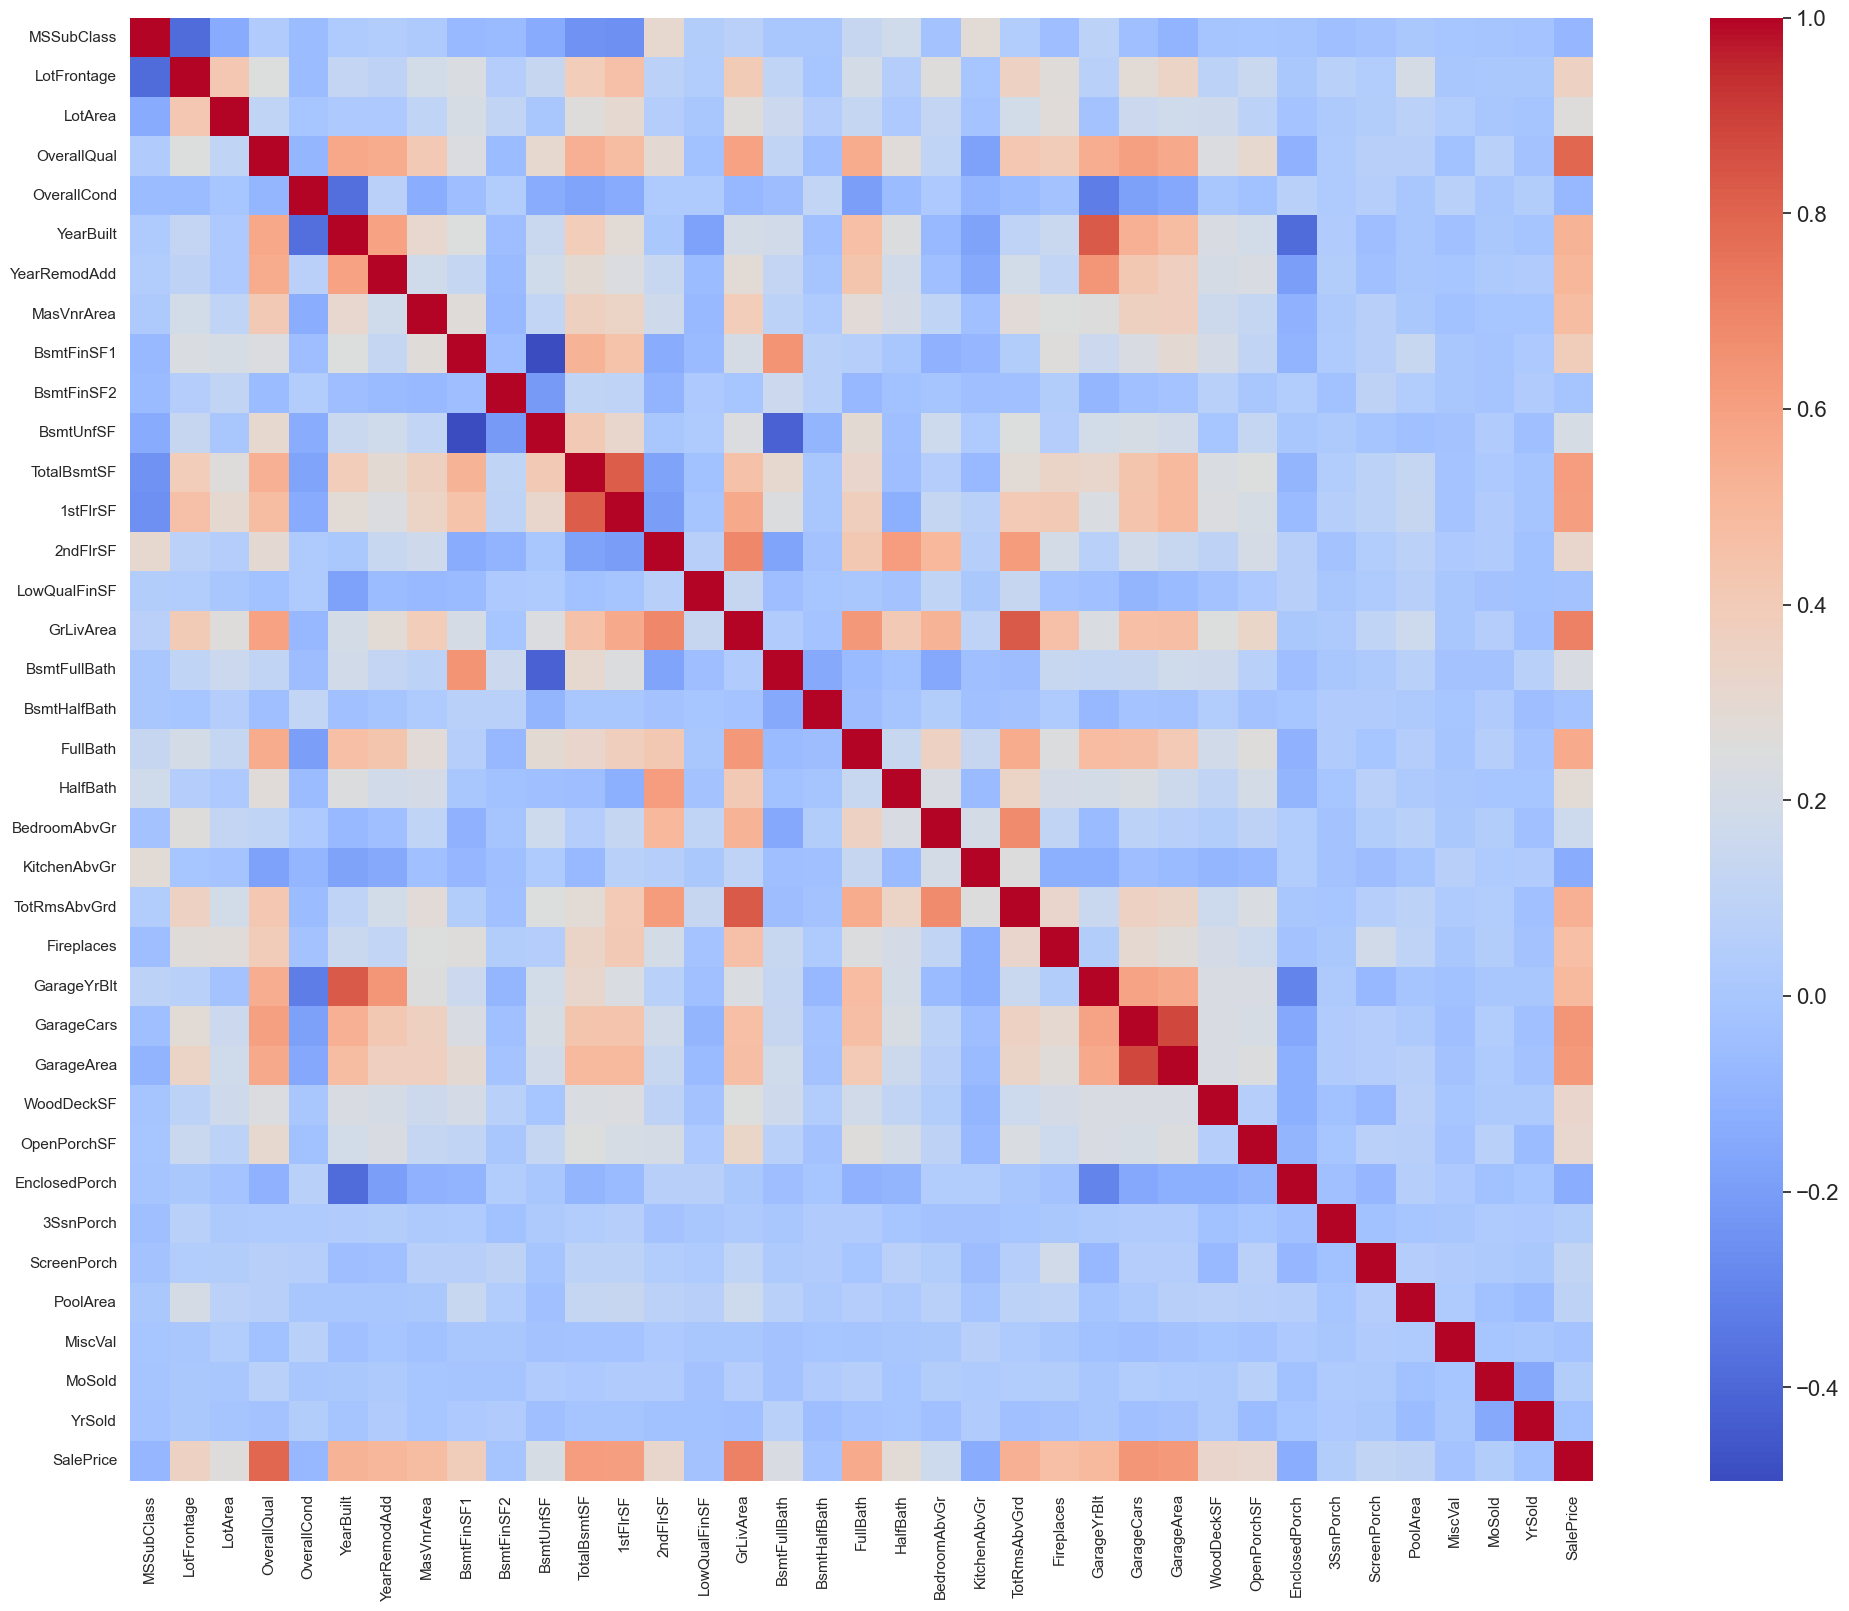

In [178]:
train_with_price = train.copy()
train_with_price['SalePrice'] = y_full
corrmat = train_with_price.corr(numeric_only=True)
f, ax = plt.subplots(figsize=(30, 19))
sns.set(font_scale=1.45)
sns.heatmap(corrmat, square=True, cmap='coolwarm')

In [179]:
correlations = corrmat["SalePrice"].sort_values(ascending=False)
features = correlations.index[0:10]
features

Index(['SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea',
       'TotalBsmtSF', '1stFlrSF', 'FullBath', 'TotRmsAbvGrd', 'YearBuilt'],
      dtype='object')

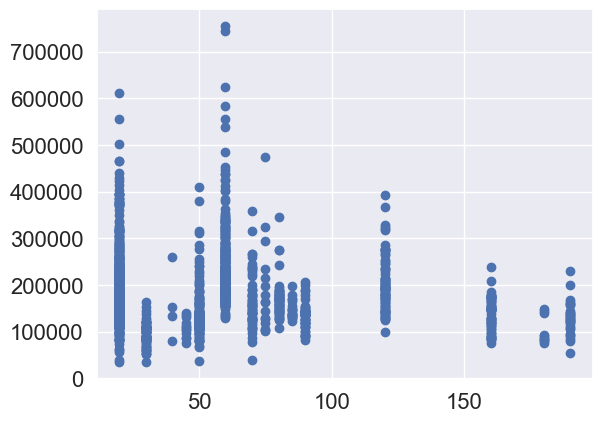

In [180]:
plt.scatter(x='MSSubClass', y='SalePrice', data=train_with_price)

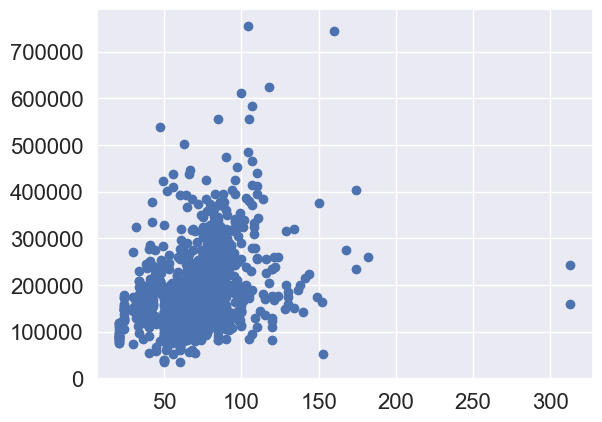

In [181]:
plt.scatter(x='LotFrontage', y='SalePrice', data=train_with_price)

In [182]:
train_with_price.query('LotFrontage > 300')
#Drop 935 and 1299

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
934,20,RL,313.0,27650,Pave,NaN,IR2,HLS,AllPub,Inside,...,0,NaN,NaN,NaN,0,11,2008,WD,Normal,242000
1298,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,Corner,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000


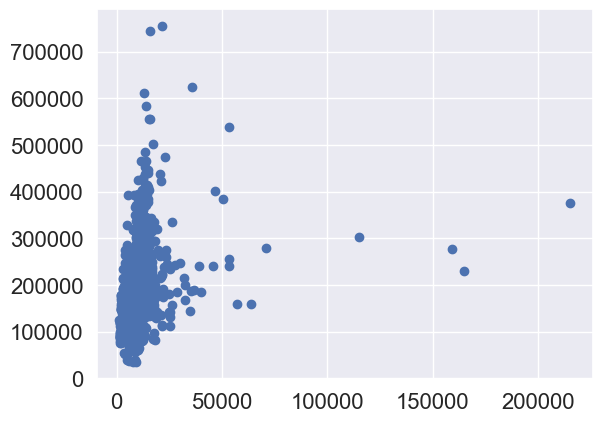

In [183]:
plt.scatter(x='LotArea', y='SalePrice', data=train_with_price)

In [184]:
train.query('LotArea > 55000')
#Drop 250, 314, 336, 707

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
249,50,RL,NaN,159000,Pave,NaN,IR2,Low,AllPub,CulDSac,...,0,0,NaN,NaN,Shed,500,6,2007,WD,Normal
313,20,RL,150.0,215245,Pave,NaN,IR3,Low,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,6,2009,WD,Normal
335,190,RL,NaN,164660,Grvl,NaN,IR1,HLS,AllPub,Corner,...,0,0,NaN,NaN,Shed,700,8,2008,WD,Normal
451,20,RL,62.0,70761,Pave,NaN,IR1,Low,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,12,2006,WD,Normal
706,20,RL,NaN,115149,Pave,NaN,IR2,Low,AllPub,CulDSac,...,0,0,NaN,NaN,NaN,0,6,2007,WD,Normal
1298,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,Corner,...,0,480,Gd,NaN,NaN,0,1,2008,New,Partial
1396,20,RL,NaN,57200,Pave,NaN,IR1,Bnk,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal


In [185]:
pd.Series(stats.zscore(train['LotArea'])).sort_values().tail(10)

384      4.268474
457      4.280500
769      4.308262
1396     4.678682
1298     5.348867
451      6.037793
706     10.486449
249     14.881285
335     15.448542
313     20.518273
dtype: float64

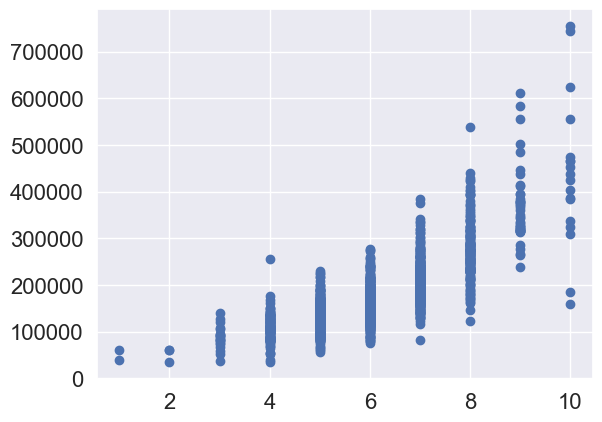

In [186]:
plt.scatter(x='OverallQual', y='SalePrice', data=train_with_price)

In [187]:
train.query('OverallQual == 10')

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
58,60,RL,66.0,13682,Pave,NaN,IR2,HLS,AllPub,CulDSac,...,0,0,NaN,NaN,NaN,0,10,2006,New,Partial
185,75,RM,90.0,22950,Pave,NaN,IR2,Lvl,AllPub,Inside,...,410,0,NaN,GdPrv,NaN,0,6,2006,WD,Normal
224,20,RL,103.0,13472,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,6,2009,WD,Normal
389,60,RL,96.0,12474,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,8,2008,New,Partial
440,20,RL,105.0,15431,Pave,NaN,Reg,Lvl,AllPub,Inside,...,170,0,NaN,NaN,NaN,0,4,2009,WD,Normal
515,20,RL,94.0,12220,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,9,2009,New,Partial
523,60,RL,130.0,40094,Pave,NaN,IR1,Bnk,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,10,2007,New,Partial
583,75,RM,75.0,13500,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,7,2008,WD,Normal
591,60,RL,97.0,13478,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,0,NaN,NaN,NaN,0,6,2009,ConLI,Normal
691,60,RL,104.0,21535,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,0,NaN,NaN,NaN,0,1,2007,WD,Normal


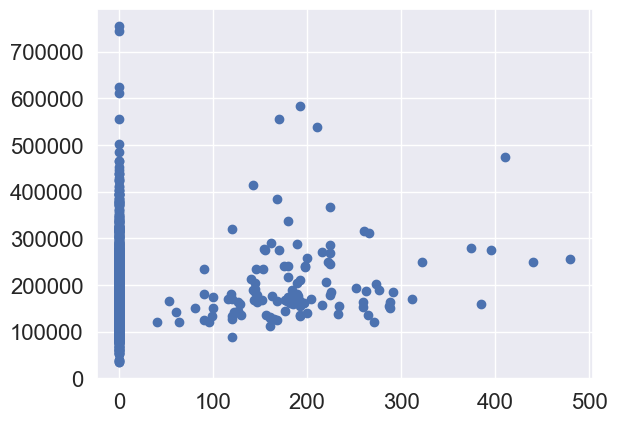

In [188]:
plt.scatter(x='ScreenPorch', y='SalePrice', data=train_with_price)

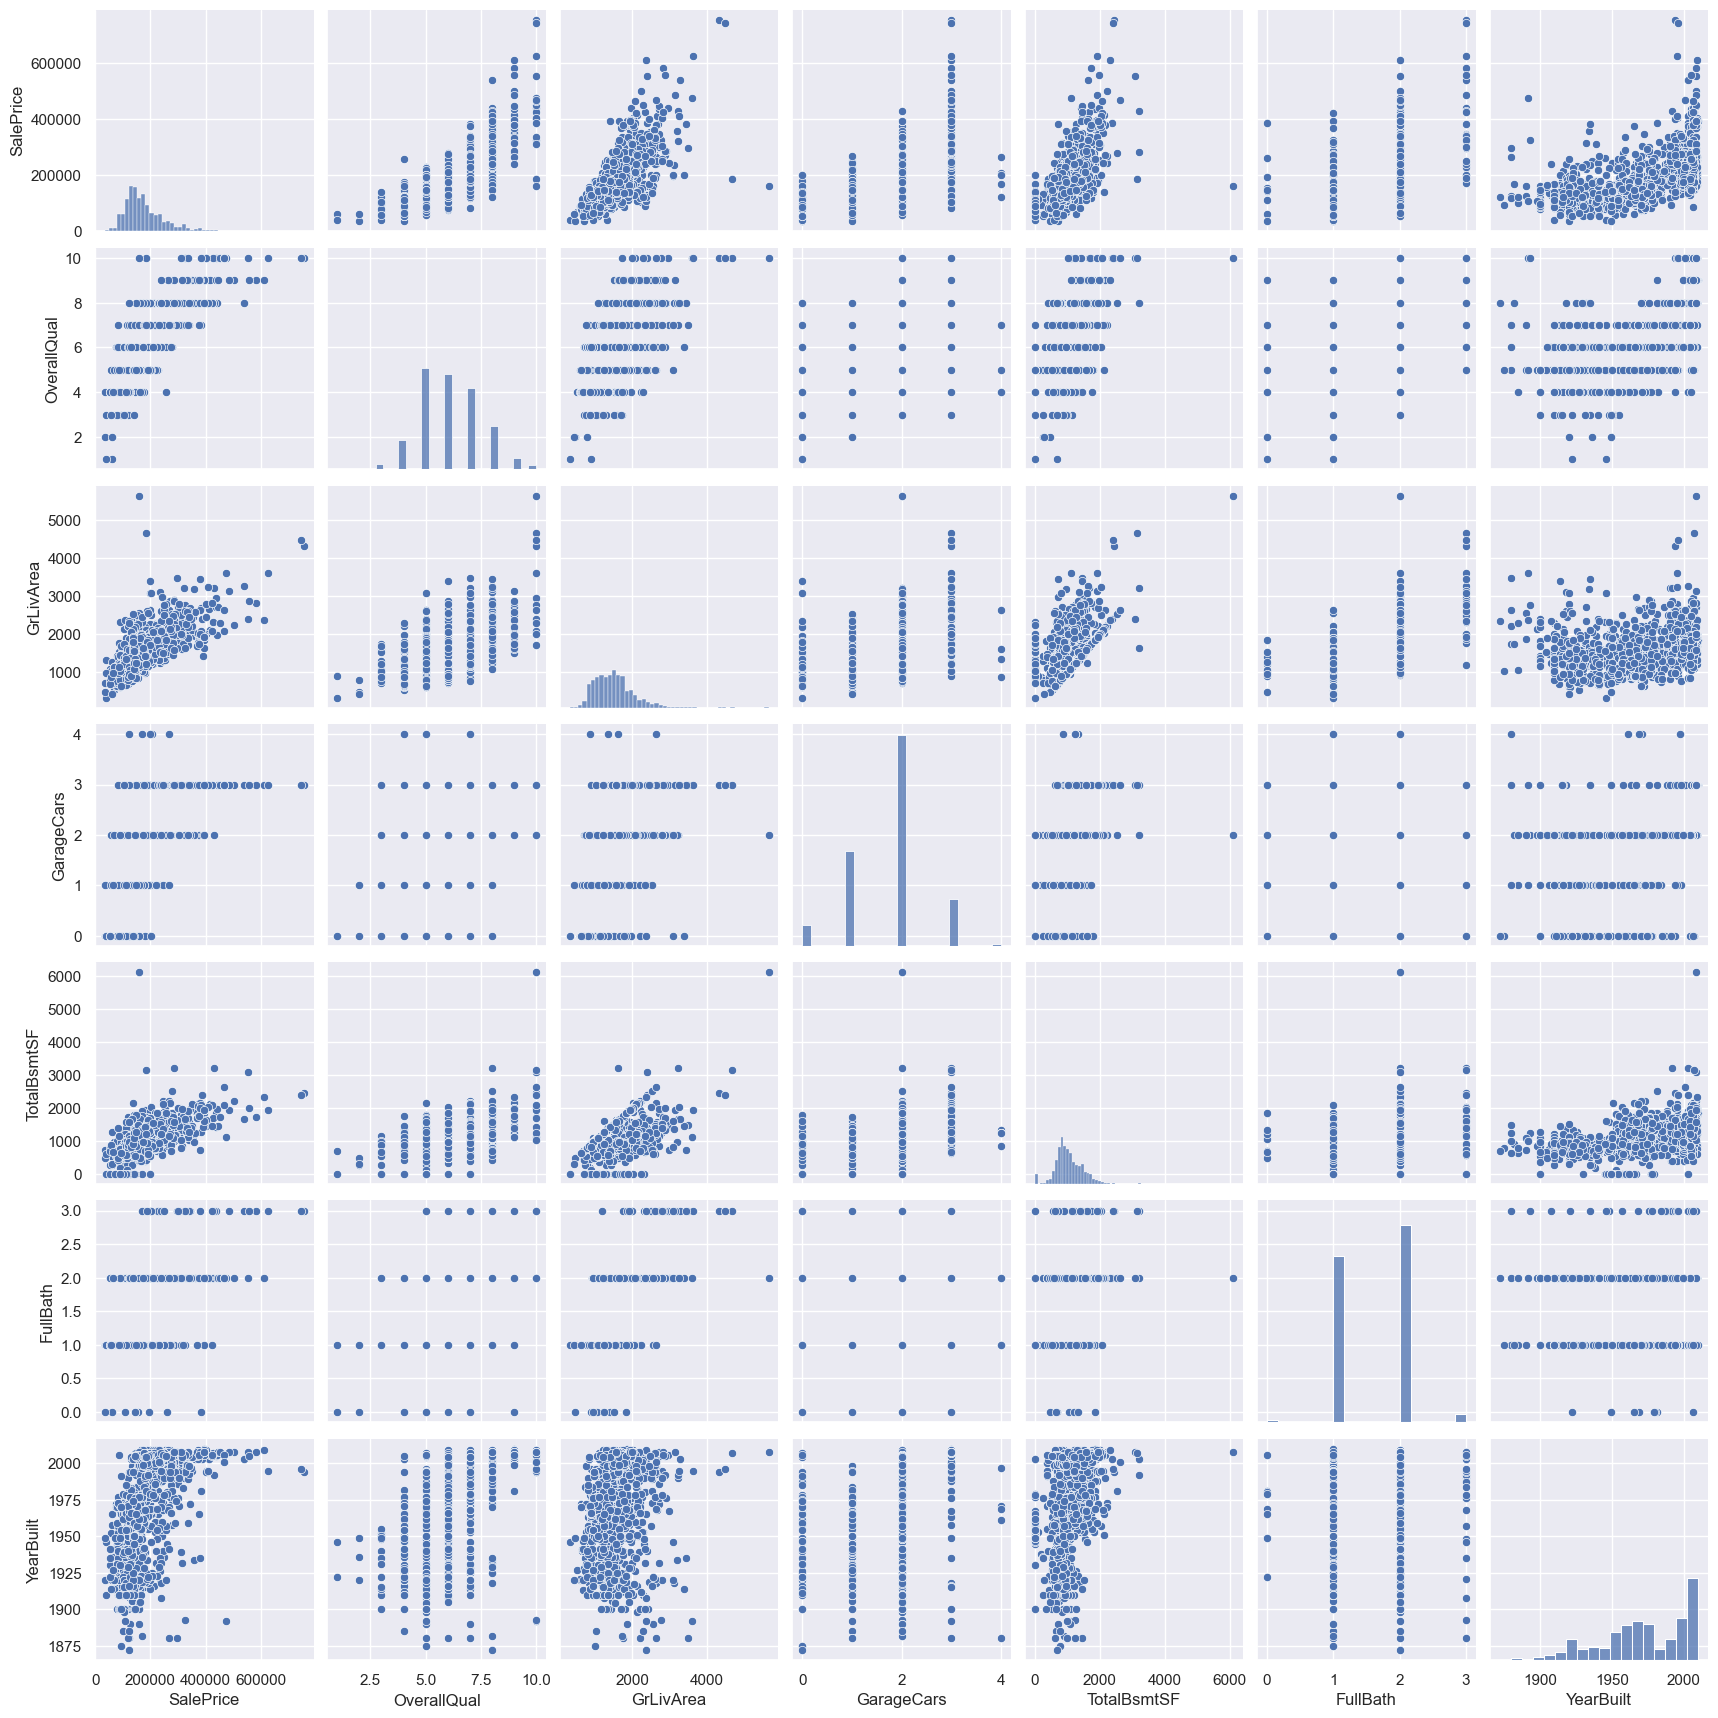

In [189]:
sns.set()
cols = ['SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'FullBath', 'YearBuilt']
sns.pairplot(train_with_price[cols], size = 2.5)
plt.show()

<Axes: >

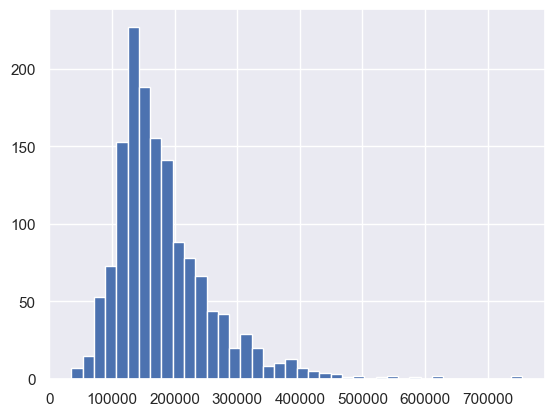

In [190]:
train_with_price['SalePrice'].hist(bins = 40)

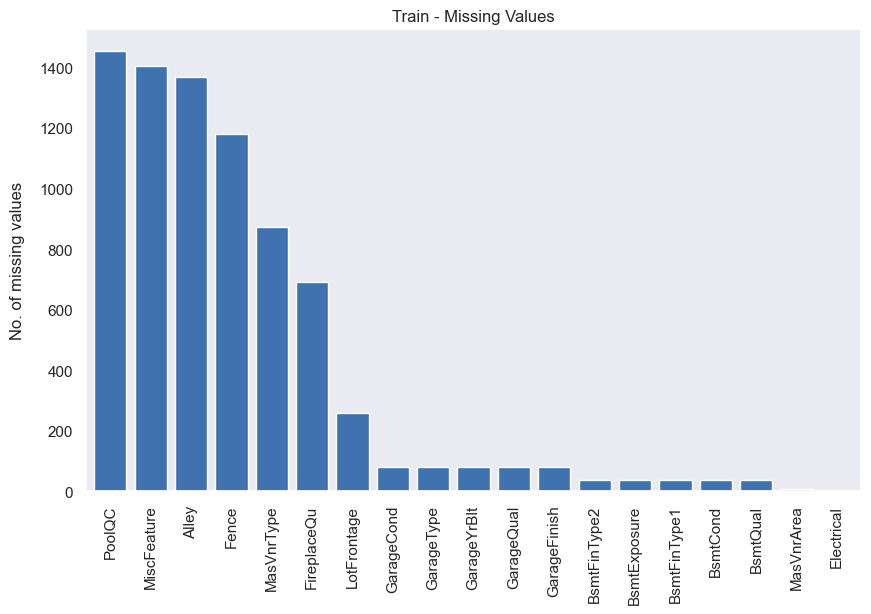

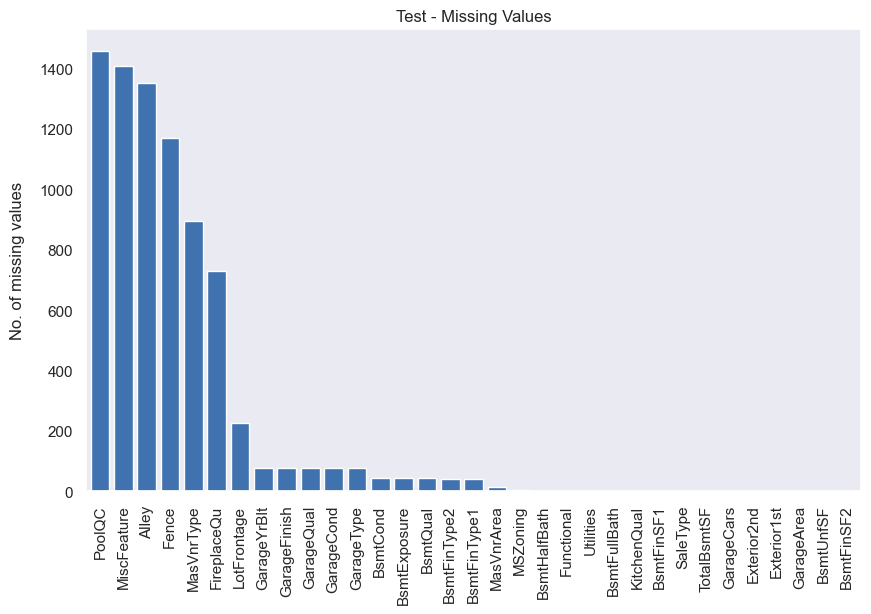

In [191]:
def plot_missing(df, title="Missing Values"):
    nans = df.isna().sum().sort_values(ascending=False)
    nans = nans[nans > 0]

    if len(nans) == 0:
        print("No missing values!")
        return

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.grid()
    ax.bar(nans.index, nans.values, zorder=2, color="#3f72af")
    ax.set_ylabel("No. of missing values", labelpad=10)
    ax.set_xlim(-0.6, len(nans) - 0.4)
    ax.xaxis.set_tick_params(rotation=90)
    plt.title(title)
    plt.show()

plot_missing(train, "Train - Missing Values")
plot_missing(test, "Test - Missing Values")


##### Discrete Values

In [192]:
numerical_features=[]
for feature in train:
    if train[feature].dtype!='O' and feature!= 'SalePrice':
        numerical_features.append(feature)

discrete_variables=[]
for feature in numerical_features:
    if len(train[feature].unique())<=25 and feature != 'SalePrice':
        discrete_variables.append(feature)

print(discrete_variables)

['MSSubClass', 'OverallQual', 'OverallCond', 'LowQualFinSF', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageCars', '3SsnPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']


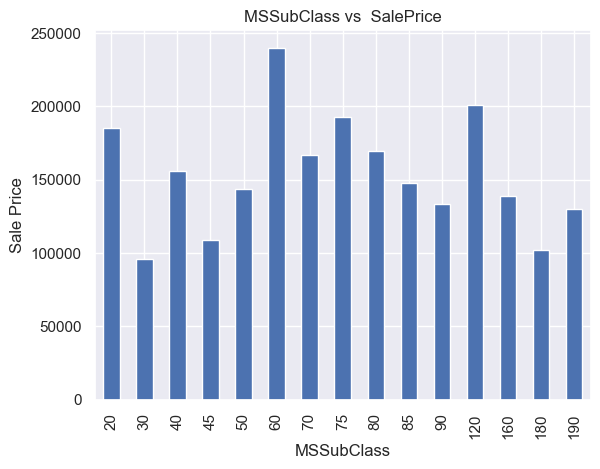

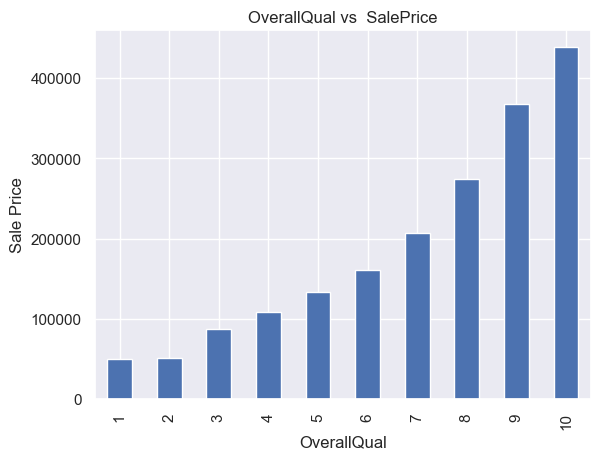

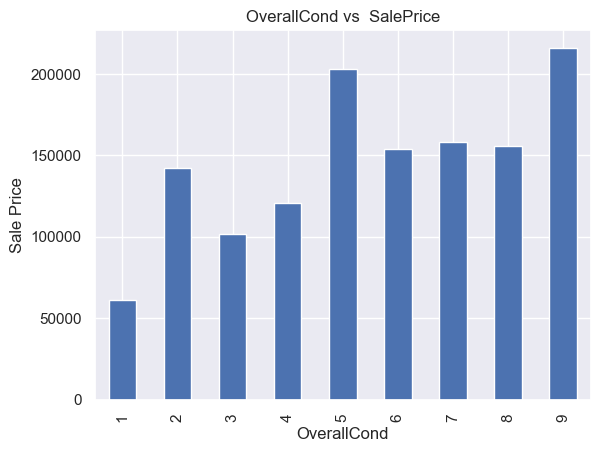

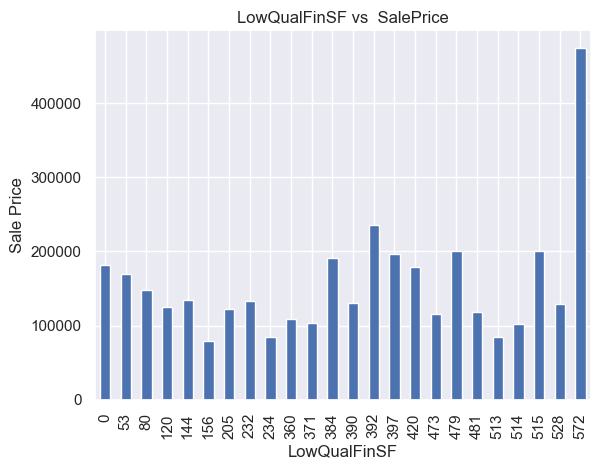

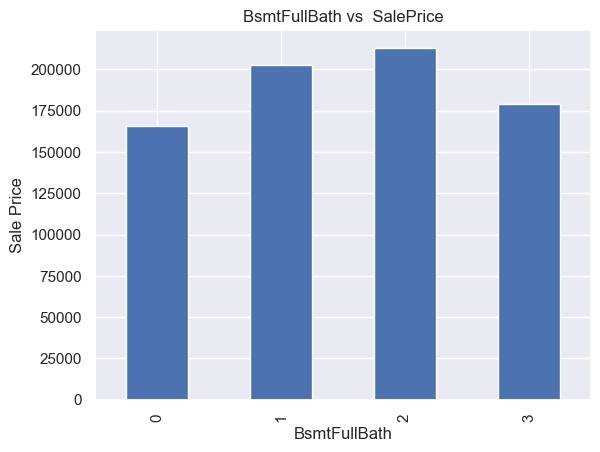

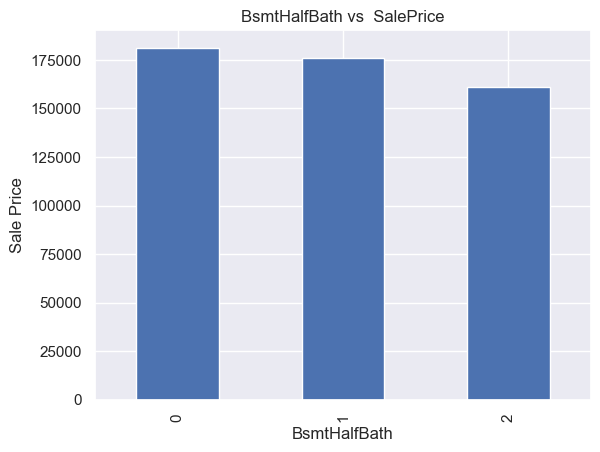

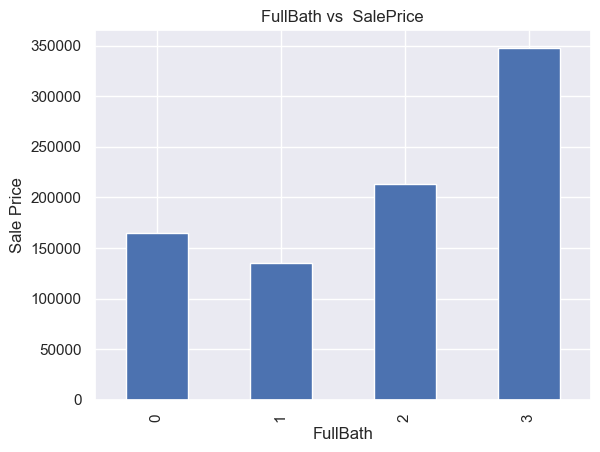

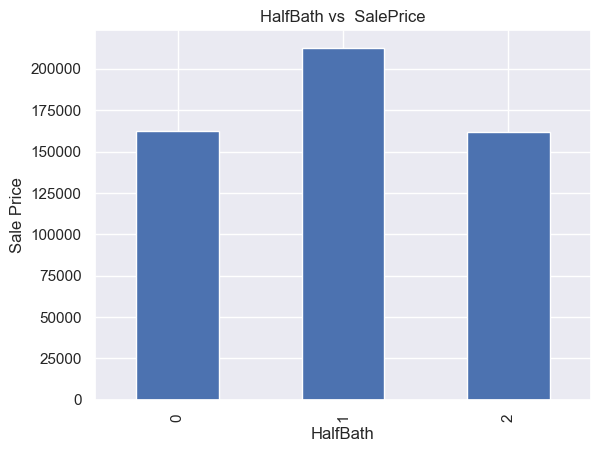

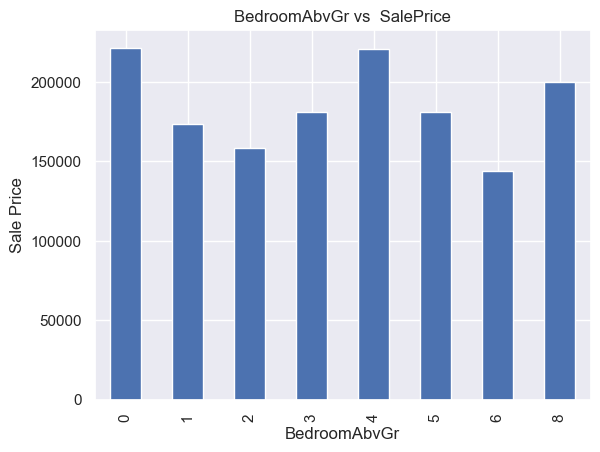

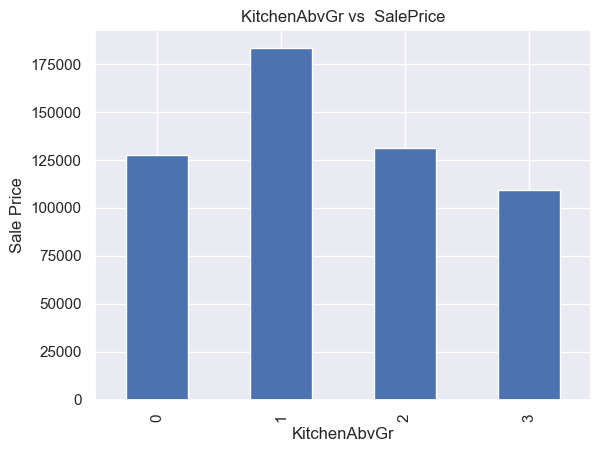

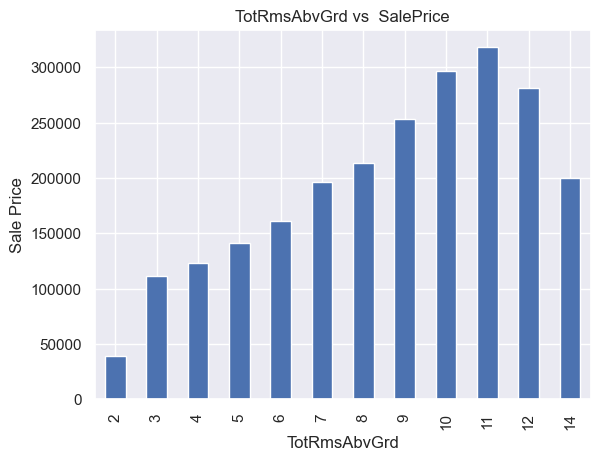

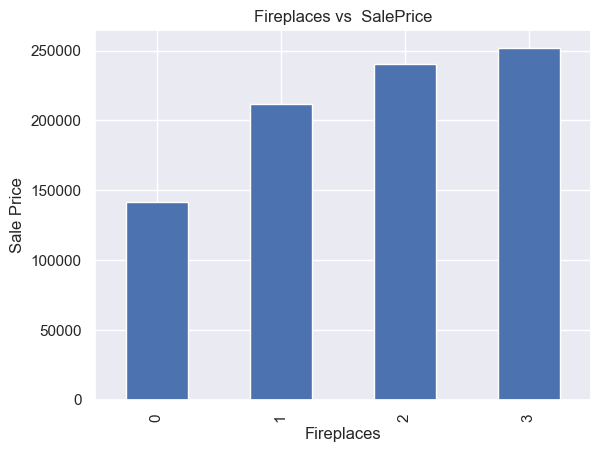

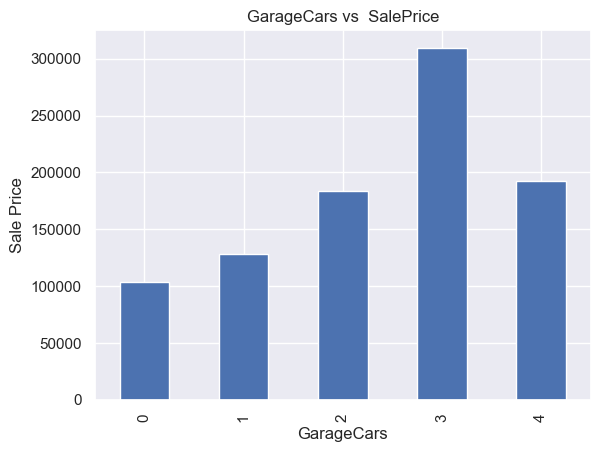

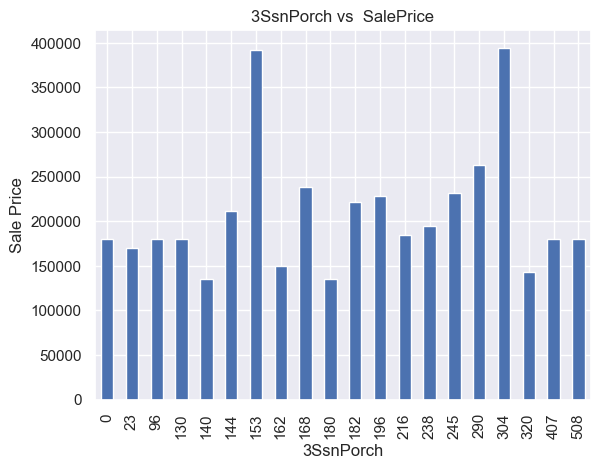

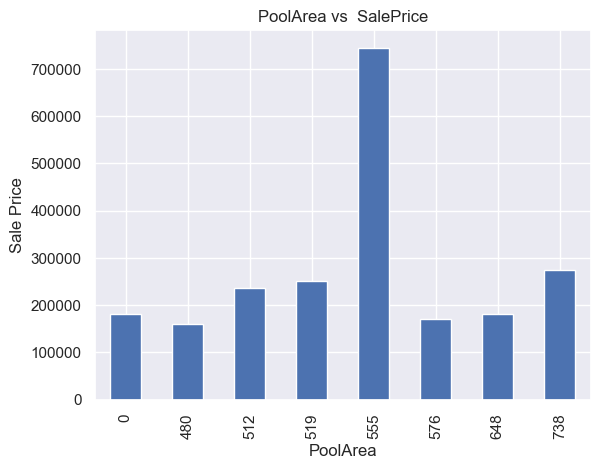

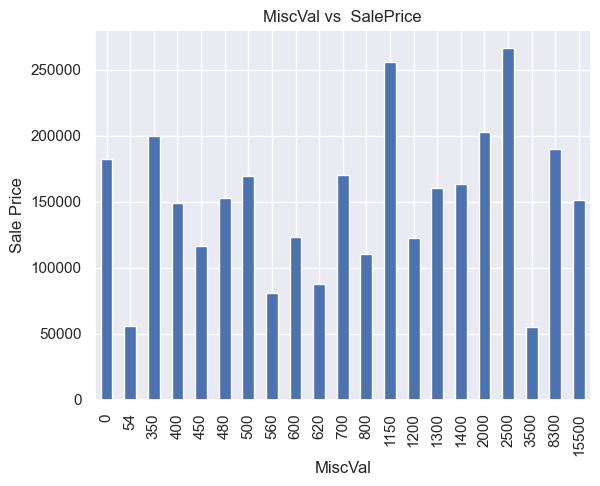

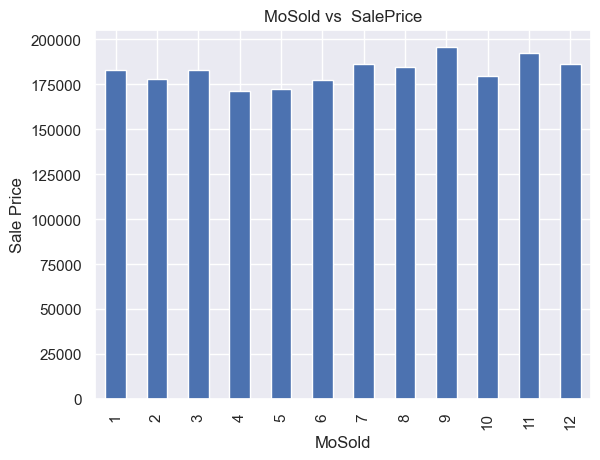

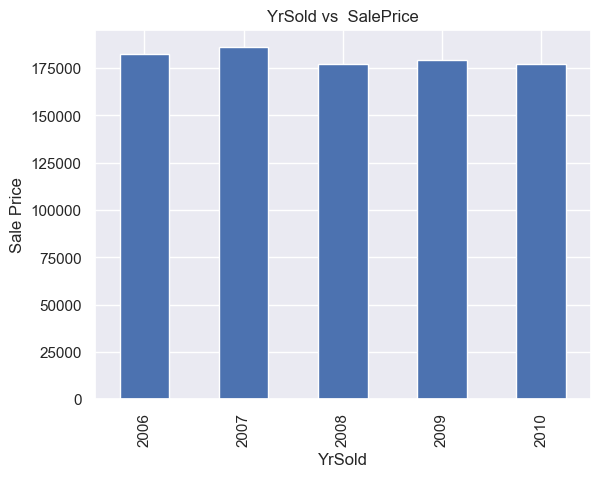

In [193]:
for feature in discrete_variables:
     train_with_price.groupby(feature)['SalePrice'].mean().plot.bar()
     plt.xlabel(feature)
     plt.ylabel('Sale Price')
     plt.title(feature +' vs '+' SalePrice')
     plt.show()

##### Continuous Values

In [194]:
continuous_variables=[]
for feature in numerical_features:
    if feature not in discrete_variables and feature not in ["YearBuilt","YearRemodAdd","GarageYrBlt","YrSold"]:
        continuous_variables.append(feature)

print(continuous_variables)

['LotFrontage', 'LotArea', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'GrLivArea', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', 'ScreenPorch']


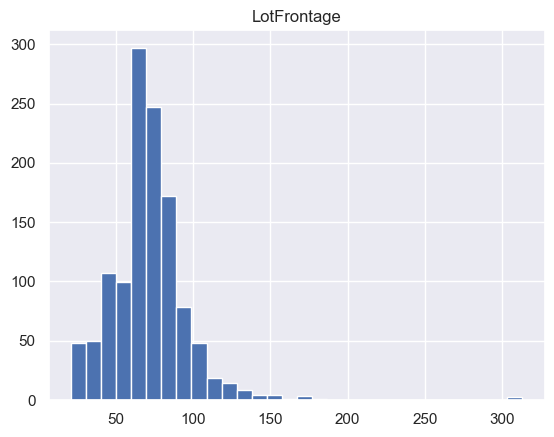

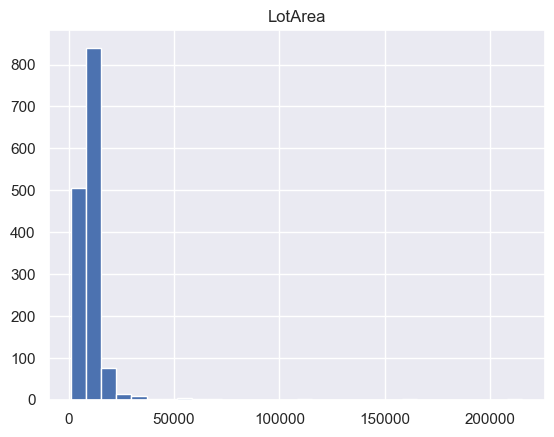

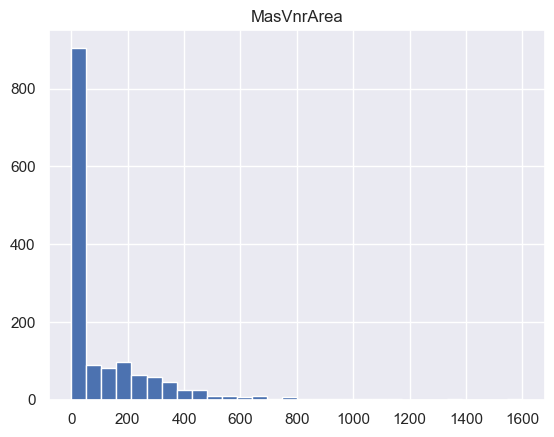

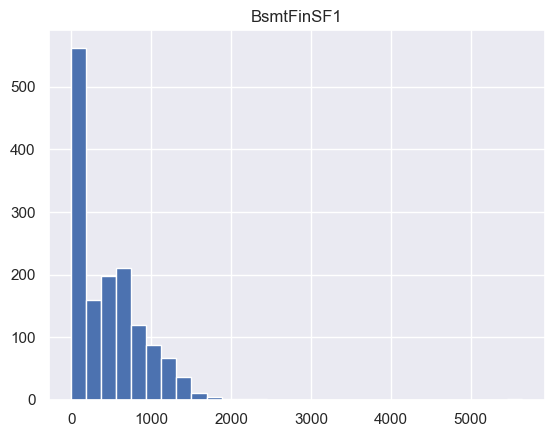

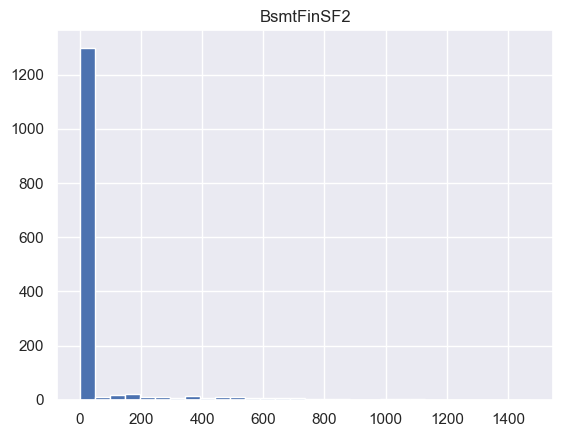

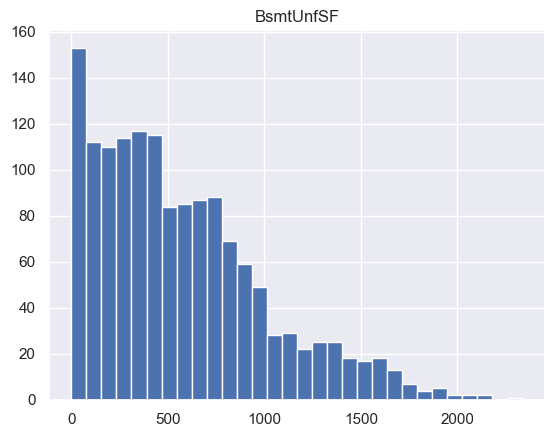

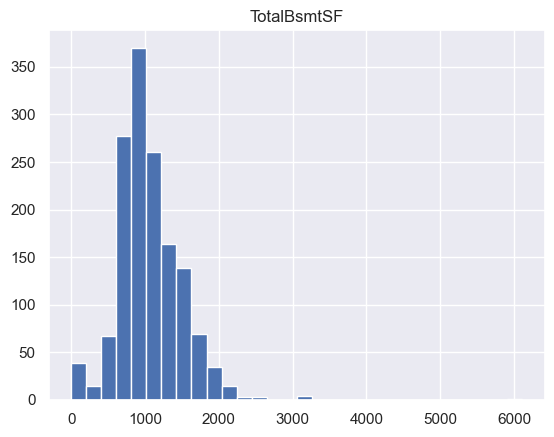

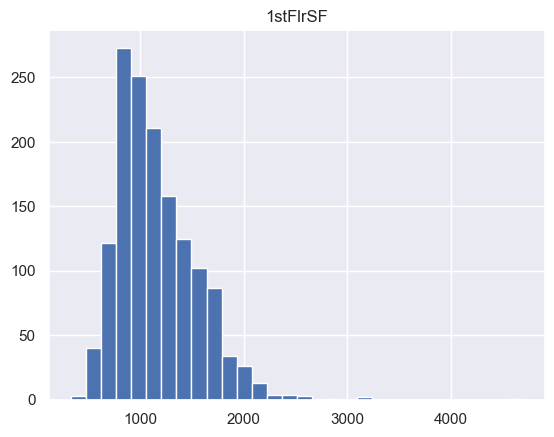

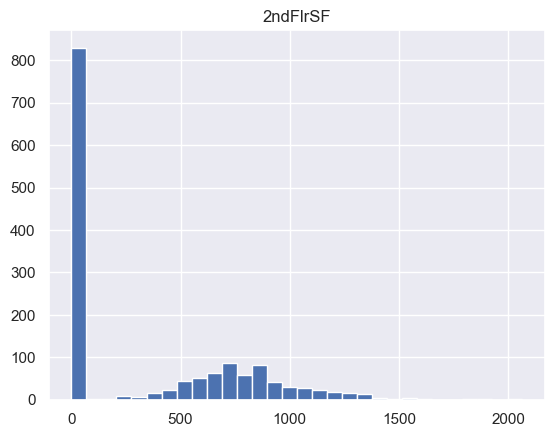

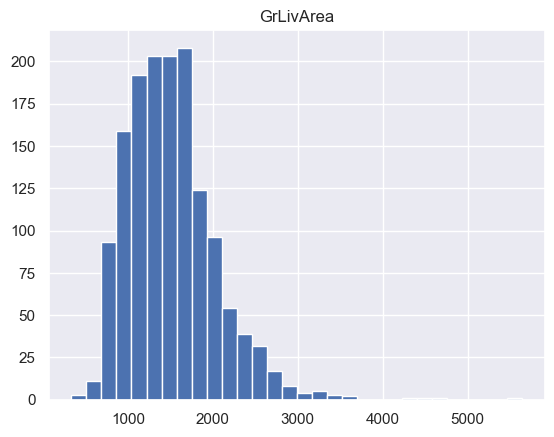

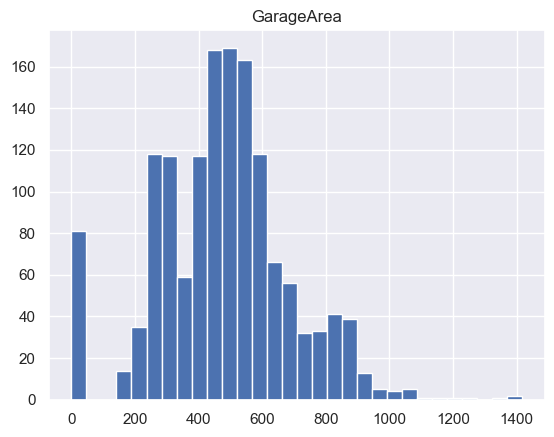

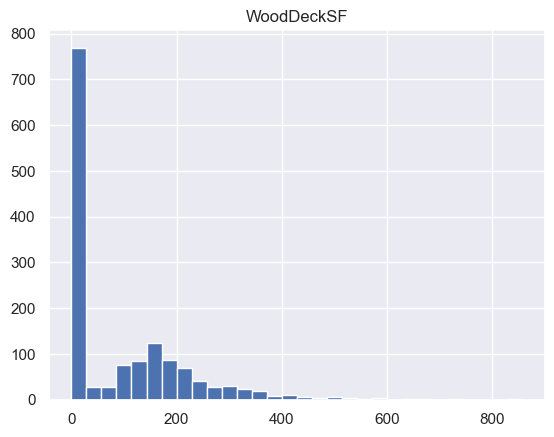

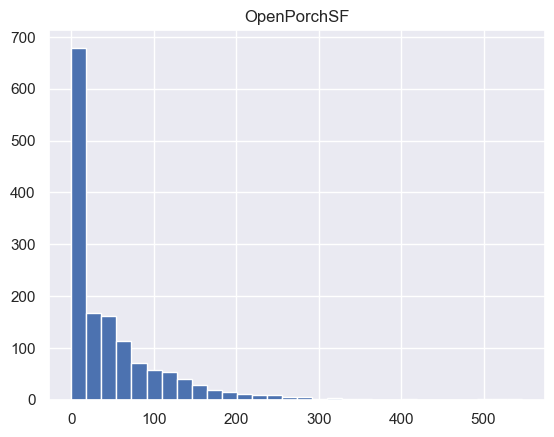

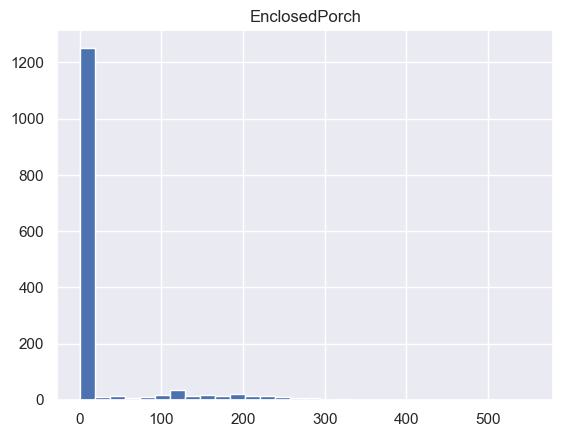

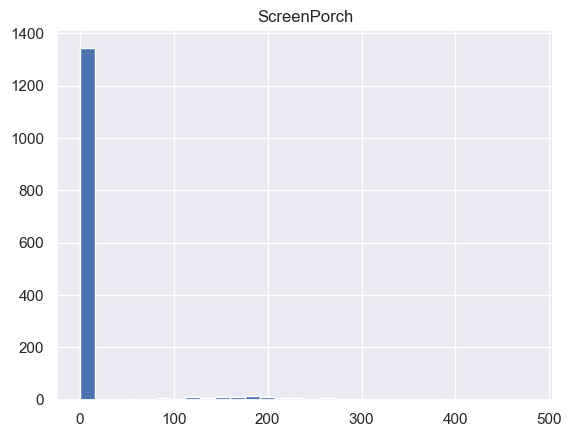

In [195]:
for feature in continuous_variables:
     train[feature].hist(bins=30)
     plt.title(feature)
     plt.show()

##### Catagorical Variables

In [196]:
categorical_features=[]
for feature in train.columns:
    if train[feature].dtype=='O'and feature!= 'SalePrice':
        categorical_features.append(feature)
print(categorical_features)

['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


<Axes: title={'center': 'Log Normal'}, xlabel='SalePrice'>

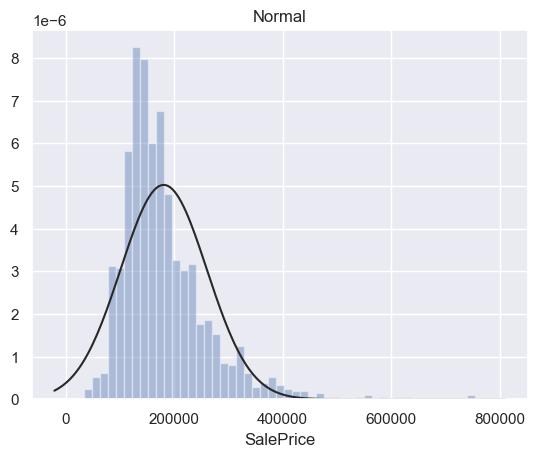

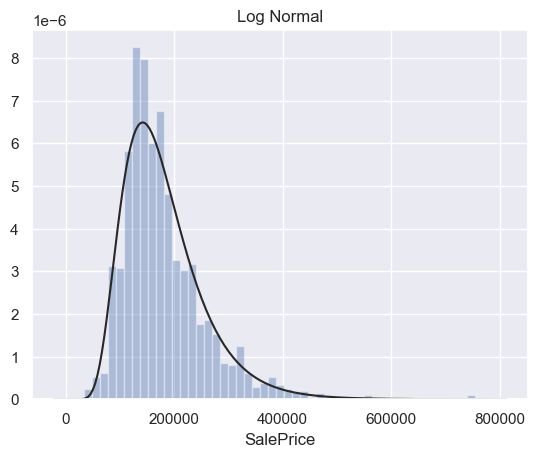

In [197]:
#Ploting the Distribution of the target variable
y1 = train_with_price['SalePrice']
plt.figure(2); plt.title('Normal')
sns.distplot(y1, kde=False, fit=stats.norm)
plt.figure(3); plt.title('Log Normal')
sns.distplot(y1, kde=False, fit=stats.lognorm)

In [198]:
training_null = pd.isnull(train).sum()
testing_null = pd.isnull(test).sum()

null = pd.concat([training_null, testing_null], axis=1, keys=["Training", "Testing"])

In [199]:
null_with_meaning = ["Alley", "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2", "FireplaceQu", "GarageType", "GarageFinish", "GarageQual", "GarageCond", "PoolQC", "Fence", "MiscFeature"]

In [200]:
for i in null_with_meaning:
    train[i].fillna("None", inplace=True)
    test[i].fillna("None", inplace=True)

In [201]:
features_modefill = ["MSZoning", "Utilities", "Exterior1st", "Exterior2nd",
                     "SaleType", "Electrical", "KitchenQual", "Functional", "MasVnrType"]

In [202]:
for col in features_modefill:
    train[col].fillna(train[col].mode()[0], inplace=True)
    test[col].fillna(test[col].mode()[0], inplace=True)

In [203]:
for col in ["LotFrontage", "GarageArea"]:
    train[col] = train.groupby("Neighborhood")[col].transform(lambda x: x.fillna(x.median()))
    test[col] = test.groupby("Neighborhood")[col].transform(lambda x: x.fillna(x.median()))

In [204]:
lot_frontage_medians = train.groupby("Neighborhood")["LotFrontage"].median().to_dict()
garage_area_medians  = train.groupby("Neighborhood")["GarageArea"].median().to_dict()
json.dump(lot_frontage_medians, open("lot_frontage_medians.json", "w"))
json.dump(garage_area_medians,  open("garage_area_medians.json",  "w"))

In [205]:
features_zerofill = ["GarageYrBlt", "MasVnrArea", "BsmtHalfBath", "BsmtFullBath",
                     "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF", "TotalBsmtSF", "GarageCars"]

In [206]:
for col in features_zerofill:
    train[col].fillna(0, inplace=True)
    test[col].fillna(0, inplace=True)

### **Feature Engineering**

In [207]:
for df in [train, test]:
    df["TotalArea"] = df["GrLivArea"] + df["TotalBsmtSF"]
    df["TotalBaths"] = df["FullBath"] + df["BsmtFullBath"] + 0.5*(df["HalfBath"] + df["BsmtHalfBath"])
    df["TotalPorch"] = df["OpenPorchSF"] + df["EnclosedPorch"] + df["3SsnPorch"] + df["ScreenPorch"]
    df["HouseAge"] = (df["YrSold"] - df["YearBuilt"]).clip(lower=0)
    df["RemodAge"] = (df["YrSold"] - df["YearRemodAdd"]).clip(lower=0)  
    df["OverallScore"] = df["OverallQual"] * df["OverallCond"]

    df["LivArea_Qual"] = df["GrLivArea"] * df["OverallQual"]
    df["LivArea_Age"]  = df["GrLivArea"] / (df["HouseAge"] + 1)  
    df["Qual_TotalArea"] = df["OverallQual"] * df["TotalArea"]

In [208]:
for df in [train, test]:
    df['Pool'] = (df['PoolArea'] > 0).astype(int)
    df['2ndFloor'] = (df['2ndFlrSF'] > 0).astype(int)
    df['Garage'] = (df['GarageCars'] > 0).astype(int)
    df['Bsmt'] = (df['TotalBsmtSF'] > 0).astype(int)
    df['Fireplace'] = (df['Fireplaces'] > 0).astype(int)
    df['Porch'] = (df['TotalPorch'] > 0).astype(int)

In [209]:
for df in [train, test]:
    df["MoSoldsin"] = np.sin(2 * np.pi * df["MoSold"] / 12)
    df["MoSoldcos"] = np.cos(2 * np.pi * df["MoSold"] / 12)
    df.drop("MoSold", axis=1, inplace=True)

In [210]:
print("Train NaNs:", train.isnull().sum().max())  # should be 0
print("Test NaNs:", test.isnull().sum().max())    # should be 0

Train NaNs: 0
Test NaNs: 0


In [211]:
#Ordinal Encoding for quality/ranked features
quality_map = {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5}
ordinal_cols = ["ExterQual", "ExterCond", "BsmtQual", "BsmtCond", "HeatingQC",
                "KitchenQual", "FireplaceQu", "GarageQual", "GarageCond", "PoolQC"]

for col in ordinal_cols:
    for df in [train, test]:
        df[col] = df[col].map(quality_map).fillna(0).astype(int)

other_ordinal = {
    "BsmtExposure": {"None": 0, "No": 1, "Mn": 2, "Av": 3, "Gd": 4},
    "BsmtFinType1": {"None": 0, "Unf": 1, "LwQ": 2, "Rec": 3, "BLQ": 4, "ALQ": 5, "GLQ": 6},
    "BsmtFinType2": {"None": 0, "Unf": 1, "LwQ": 2, "Rec": 3, "BLQ": 4, "ALQ": 5, "GLQ": 6},
    "GarageFinish": {"None": 0, "Unf": 1, "RFn": 2, "Fin": 3},
    "Fence": {"None": 0, "MnWw": 1, "GdWo": 2, "MnPrv": 3, "GdPrv": 4},
    "Functional": {"Sal": 1, "Sev": 2, "Maj2": 3, "Maj1": 4, "Mod": 5, "Min2": 6, "Min1": 7, "Typ": 8},
    "LandSlope": {"Sev": 1, "Mod": 2, "Gtl": 3},
    "LotShape": {"IR3": 1, "IR2": 2, "IR1": 3, "Reg": 4},
    "PavedDrive": {"N": 0, "P": 1, "Y": 2},
    "Street": {"Grvl": 0, "Pave": 1},
    "CentralAir": {"N": 0, "Y": 1},
    "Utilities": {"ELO": 1, "NoSeWa": 2, "NoSewr": 3, "AllPub": 4},
}

for col, mapping in other_ordinal.items():
    for df in [train, test]:
        if col in df.columns:
            df[col] = df[col].map(mapping).fillna(0).astype(int)

encoded_ordinal = ordinal_cols + list(other_ordinal.keys())
print(f"Ordinal encoded: {len(encoded_ordinal)} columns")

#One-Hot Encoding for nominal features
nominal_cols = [c for c in train.select_dtypes(include="object").columns]
train = pd.get_dummies(train, columns=nominal_cols, drop_first=False)
test  = pd.get_dummies(test,  columns=nominal_cols, drop_first=False)

train, test = train.align(test, join="left", axis=1, fill_value=0)
train_columns = train.columns.tolist()
json.dump(train_columns, open("train_columns.json", "w"))

print(f"Final train shape: {train.shape}")
print(f"Final test shape: {test.shape}")

Ordinal encoded: 22 columns
Final train shape: (1460, 238)
Final test shape: (1459, 238)


In [212]:
train_clean = train.copy()
mask = (
    ~((train_clean["GrLivArea"] > 4000) & (y_full < 300000)) &
    (train_clean["LotArea"] < 100000) &
    (y_full < 700000)
)
train_clean = train_clean[mask]
train_clean["SalePrice"] = y_full[mask]  

In [213]:
from scipy.stats import skew
import json

numeric_feats = train_clean.drop(columns=["SalePrice"]).select_dtypes(include=[np.number]).columns
skewed_feats = train_clean[numeric_feats].apply(lambda x: skew(x.dropna())).sort_values(ascending=False)
high_skew = skewed_feats[abs(skewed_feats) > 0.75]

# Save the list before transforming
skewed_feature_list = high_skew.index.tolist()
json.dump(skewed_feature_list, open('skewed_features.json', 'w'))

# Only transform train_clean not test
for col in skewed_feature_list:
    train_clean.loc[:, col] = np.log1p(train_clean[col].clip(lower=0))

print(f"Skew corrected {len(skewed_feature_list)} features on train only")

Skew corrected 47 features on train only


### **Feature Selection**

In [214]:
X = train_clean.drop(columns=['SalePrice'])
y = np.log1p(train_clean['SalePrice'])

In [215]:
selector = SelectKBest(f_regression, k=30)
selector.fit(X, y)

,"score_func score_func: callable, default=f_classifFunction taking two arrays X and y, and returning a pair of arrays(scores, pvalues) or a single array with scores.Default is f_classif (see below ""See Also""). The default function onlyworks with classification tasks... versionadded:: 0.18",<function f_r...t 0x13216f420>
,"k k: int or ""all"", default=10Number of top features to select.The ""all"" option bypasses selection, for use in a parameter search.",30


In [216]:
feature_scores = pd.DataFrame({
    'feature': X.columns,
    'score': selector.scores_
}).sort_values('score', ascending=False)

print("Top 30 features:")
print(feature_scores.head(30))

Top 30 features:
               feature        score
65      Qual_TotalArea  5006.996219
63        LivArea_Qual  3714.054372
7          OverallQual  2998.995467
57           TotalArea  2893.888672
28           GrLivArea  1675.641755
64         LivArea_Age  1606.307049
12           ExterQual  1272.763113
42          GarageCars  1256.330713
58          TotalBaths  1192.412993
35         KitchenQual  1179.883174
43          GarageArea  1096.695838
22         TotalBsmtSF  1002.062942
25            1stFlrSF   853.944490
41        GarageFinish   841.809980
62        OverallScore   839.152712
60            HouseAge   783.353343
9            YearBuilt   780.831384
31            FullBath   774.713371
61            RemodAge   712.434338
10        YearRemodAdd   703.431484
39         FireplaceQu   613.556228
196   Foundation_PConc   586.676154
36        TotRmsAbvGrd   580.342669
70           Fireplace   507.392309
14            BsmtQual   479.510272
38          Fireplaces   441.851979
23         

In [217]:
selected_features = feature_scores.head(30)['feature'].tolist()
print(f"\nSelected {len(selected_features)} features out of {X.shape[1]}")


Selected 30 features out of 238


### Feature Selection - SelectFromModel (Random Forest)

In [218]:
from sklearn.feature_selection import SelectFromModel

X_all = train_clean.drop(columns=["SalePrice"])
y_all = np.log1p(train_clean["SalePrice"])

rf_selector = RandomForestRegressor(n_estimators=200, random_state=42, max_depth=10, n_jobs=-1)
rf_selector.fit(X_all, y_all)

sfm = SelectFromModel(rf_selector, threshold="median")
sfm.fit(X_all, y_all)
rf_selected_features = X_all.columns[sfm.get_support()].tolist()

importances = pd.Series(rf_selector.feature_importances_, index=X_all.columns).sort_values(ascending=False)
print(f"SelectFromModel (RF) selected {len(rf_selected_features)} features")
print(f"\nTop 20 features by RF importance:")
print(importances.head(20))

SelectFromModel (RF) selected 119 features

Top 20 features by RF importance:
Qual_TotalArea    0.782765
LivArea_Age       0.028620
LivArea_Qual      0.020668
CentralAir        0.009155
LotArea           0.008539
BsmtUnfSF         0.007886
OverallScore      0.007178
BsmtFinSF1        0.006927
RemodAge          0.006639
GarageArea        0.006612
TotalArea         0.005347
1stFlrSF          0.004750
YearRemodAdd      0.004693
GarageYrBlt       0.004632
TotalBaths        0.004289
MSZoning_RM       0.004219
OverallCond       0.003962
GrLivArea         0.003728
LotFrontage       0.003483
HouseAge          0.003420
dtype: float64


In [219]:
#Feature Selection Method 3: Lasso coefficients
from sklearn.linear_model import LassoCV

X_all = train_clean.drop(columns=["SalePrice"])
y_all = np.log1p(train_clean["SalePrice"])

lasso_selector = LassoCV(cv=5, random_state=42, max_iter=10000)
lasso_selector.fit(X_all, y_all)

# features with nonzero coefficients
lasso_mask = lasso_selector.coef_ != 0
lasso_selected_features = X_all.columns[lasso_mask].tolist()

print(f"LassoCV best alpha: {lasso_selector.alpha_:.6f}")
print(f"Lasso selected {len(lasso_selected_features)} features out of {X_all.shape[1]}")
print(f"Zeroed out: {X_all.shape[1] - len(lasso_selected_features)} features")

LassoCV best alpha: 0.244887
Lasso selected 6 features out of 238
Zeroed out: 232 features


### **Cross Validation**

In [220]:
from sklearn.model_selection import KFold

def cv_score(model, X, y, cv=5):
    kf = KFold(n_splits=cv, shuffle=True, random_state=42)
    scores = cross_val_score(model, X, y, cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1)
    rmse_scores = -scores
    return rmse_scores.mean(), rmse_scores.std()

In [221]:
from mlflow.models import infer_signature

def log_model_with_signature(log_fn, model, X_train, run_name="model"):
    signature = infer_signature(X_train, model.predict(X_train))
    log_fn(model, run_name, signature=signature)

In [222]:
import os

os.makedirs("artifacts", exist_ok=True)

def log_residual_plot(model_name, y_test, test_pred):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    axes[0].scatter(np.expm1(y_test), np.expm1(test_pred), alpha=0.5, color='steelblue')
    axes[0].plot([np.expm1(y_test).min(), np.expm1(y_test).max()],
                 [np.expm1(y_test).min(), np.expm1(y_test).max()], 'r--')
    axes[0].set_xlabel("Actual Price")
    axes[0].set_ylabel("Predicted Price")
    axes[0].set_title(f"{model_name} — Actual vs Predicted")

    residuals = np.expm1(y_test) - np.expm1(test_pred)
    axes[1].scatter(np.expm1(test_pred), residuals, alpha=0.5, color='steelblue')
    axes[1].axhline(0, color='red', linestyle='--')
    axes[1].set_xlabel("Predicted Price")
    axes[1].set_ylabel("Residual")
    axes[1].set_title(f"{model_name} — Residuals")

    plt.tight_layout()
    path = f"artifacts/{model_name}_residuals.png"
    plt.savefig(path)
    plt.close()
    return path

## **Training**

### **Linear Regression**

In [223]:
with mlflow.start_run(run_name="linear_regression_baseline"):
    X = train_clean.drop(columns=['SalePrice'])
    y = np.log1p(train_clean['SalePrice'])
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    cv_mean, cv_std = cv_score(model, X_train, y_train)
    train_pred = model.predict(X_train)
    test_pred  = model.predict(X_test)
    train_rmse = np.sqrt(mean_squared_error(np.expm1(y_train), np.expm1(train_pred)))
    test_rmse  = np.sqrt(mean_squared_error(np.expm1(y_test),  np.expm1(test_pred)))
    r2         = r2_score(y_test, test_pred)

    artifact_path = log_residual_plot("linear_baseline", y_test, test_pred)
    mlflow.log_artifact(artifact_path)
    
    mlflow.log_param("model_type", "LinearRegression")
    mlflow.log_param("feature_selection", "none")
    mlflow.log_param("n_features", X.shape[1])
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("test_rmse", test_rmse)
    mlflow.log_metric("r2", r2)
    mlflow.log_metric("cv_rmse_mean",     cv_mean)
    mlflow.log_metric("cv_rmse_std",      cv_std)
    mlflow.log_metric("train_test_ratio", train_rmse / test_rmse)
    log_model_with_signature(mlflow.sklearn.log_model, model, X_train)
    print(f"Train RMSE: {train_rmse:,.0f}")
    print(f"Test RMSE:  {test_rmse:,.0f} | R2: {r2:.4f}")

2026/04/13 16:05:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 16:05:10 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Train RMSE: 16,481
Test RMSE:  21,050 | R2: 0.9119
🏃 View run linear_regression_baseline at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0/runs/4a7bce895cec457095e37cef39e162ca
🧪 View experiment at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0


In [224]:
with mlflow.start_run(run_name="linear_regression_selectkbest_k30"):
    X_selected = train_clean[selected_features]
    y = np.log1p(train_clean['SalePrice'])

    X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

    model = LinearRegression()
    model.fit(X_train, y_train)

    cv_mean, cv_std = cv_score(model, X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_rmse = np.sqrt(mean_squared_error(np.expm1(y_train), np.expm1(train_pred)))
    test_rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(test_pred)))
    r2 = r2_score(y_test, test_pred)

    mlflow.log_param("model_type", "LinearRegression")
    mlflow.log_param("feature_selection", "SelectKBest")
    mlflow.log_param("k_features", 30)
    mlflow.log_param("log_transform", True)
    mlflow.log_param("outlier_removal", "zscore_3")
    mlflow.log_param("feature_engineering", True)
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("test_rmse", test_rmse)
    mlflow.log_metric("r2", r2)
    mlflow.log_metric("cv_rmse_mean",     cv_mean)
    mlflow.log_metric("cv_rmse_std",      cv_std)
    mlflow.log_metric("train_test_ratio", train_rmse / test_rmse)
    log_model_with_signature(mlflow.sklearn.log_model, model, X_train)

    print(f"Train RMSE: {train_rmse:,.0f}")
    print(f"Test RMSE:  {test_rmse:,.0f} | R2: {r2:.4f}")

2026/04/13 16:05:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 16:05:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Train RMSE: 24,229
Test RMSE:  24,369 | R2: 0.8890
🏃 View run linear_regression_selectkbest_k30 at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0/runs/f94b7974d9764d079185ddb9b9696e19
🧪 View experiment at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0


In [225]:
with mlflow.start_run(run_name="linear_regression_underfit"):
    underfit_features = ['GrLivArea', 'OverallQual', 'YearBuilt']

    X = train_clean[underfit_features]
    y = np.log1p(train_clean['SalePrice'])

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = LinearRegression()
    model.fit(X_train, y_train)

    cv_mean, cv_std = cv_score(model, X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_rmse = np.sqrt(mean_squared_error(np.expm1(y_train), np.expm1(train_pred)))
    test_rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(test_pred)))
    r2 = r2_score(y_test, test_pred)

    mlflow.log_param("model_type", "LinearRegression_underfit")
    mlflow.log_param("features_used", 3)
    mlflow.log_param("feature_list", "GrLivArea, OverallQual, YearBuilt")
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("test_rmse", test_rmse)
    mlflow.log_metric("r2", r2)
    mlflow.log_metric("cv_rmse_mean",     cv_mean)
    mlflow.log_metric("cv_rmse_std",      cv_std)
    mlflow.log_metric("train_test_ratio", train_rmse / test_rmse)
    log_model_with_signature(mlflow.sklearn.log_model, model, X_train)

    print(f"Train RMSE: {train_rmse:,.0f}")
    print(f"Test RMSE:  {test_rmse:,.0f}")
    print(f"R2: {r2:.4f}")

2026/04/13 16:06:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 16:06:13 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Train RMSE: 33,950
Test RMSE:  32,720
R2: 0.8117
🏃 View run linear_regression_underfit at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0/runs/c621d90ff81f4380a67d8786ff62231f
🧪 View experiment at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0


### **Ridge**

In [226]:
with mlflow.start_run(run_name="ridge_overfit_attempt"):
    X = train_clean.drop(columns=['SalePrice'])
    y = np.log1p(train_clean['SalePrice'])

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = Ridge(alpha=0.0001)  
    model.fit(X_train, y_train)

    cv_mean, cv_std = cv_score(model, X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_rmse = np.sqrt(mean_squared_error(np.expm1(y_train), np.expm1(train_pred)))
    test_rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(test_pred)))
    r2 = r2_score(y_test, test_pred)

    mlflow.log_param("model_type", "Ridge")
    mlflow.log_param("alpha", 0.0001)
    mlflow.log_param("log_transform", True)
    mlflow.log_param("outlier_removal", "zscore_3")
    mlflow.log_param("feature_engineering", True)
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("test_rmse", test_rmse)
    mlflow.log_metric("train_test_ratio", train_rmse / test_rmse) 
    mlflow.log_metric("r2", r2)
    mlflow.log_metric("cv_rmse_mean",     cv_mean)
    mlflow.log_metric("cv_rmse_std",      cv_std)
    log_model_with_signature(mlflow.sklearn.log_model, model, X_train)

    print(f"Train RMSE: {train_rmse:,.0f}")
    print(f"Test RMSE:  {test_rmse:,.0f}")
    print(f"R2: {r2:.4f}")

2026/04/13 16:06:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 16:06:45 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Train RMSE: 16,484
Test RMSE:  21,073
R2: 0.9118
🏃 View run ridge_overfit_attempt at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0/runs/085d4f06253d44dfb2be88f5999915a5
🧪 View experiment at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0


In [227]:
from sklearn.model_selection import GridSearchCV

with mlflow.start_run(run_name="ridge_baseline2"):
    X = train_clean.drop(columns=['SalePrice'])
    y = np.log1p(train_clean['SalePrice'])

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    param_grid = {'alpha': [0.01, 0.1, 1, 10, 50, 100, 200]}
    model = GridSearchCV(Ridge(), param_grid, cv=5, scoring='neg_root_mean_squared_error')
    model.fit(X_train, y_train)

    cv_mean, cv_std = cv_score(model, X_train, y_train)
    best_alpha = model.best_params_['alpha']

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_rmse = np.sqrt(mean_squared_error(np.expm1(y_train), np.expm1(train_pred)))
    test_rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(test_pred)))
    r2 = r2_score(y_test, test_pred)

    mlflow.log_param("model_type", "Ridge")
    mlflow.log_param("best_alpha", best_alpha)
    mlflow.log_param("log_transform", True)
    mlflow.log_param("outlier_removal", "zscore_3")
    mlflow.log_param("feature_engineering", True)
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("test_rmse", test_rmse)
    mlflow.log_metric("r2", r2)
    mlflow.log_metric("cv_rmse_mean",     cv_mean)
    mlflow.log_metric("cv_rmse_std",      cv_std)
    mlflow.log_metric("train_test_ratio", train_rmse / test_rmse)
    log_model_with_signature(mlflow.sklearn.log_model, model, X_train)

    print(f"Best alpha: {best_alpha}")
    print(f"Train RMSE: {train_rmse:,.0f}")
    print(f"Test RMSE:  {test_rmse:,.0f} | R2: {r2:.4f}")

2026/04/13 16:07:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 16:07:17 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Best alpha: 10
Train RMSE: 17,478
Test RMSE:  20,688 | R2: 0.9165
🏃 View run ridge_baseline2 at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0/runs/cae9ff9240a84b5091af929f27ffe9e6
🧪 View experiment at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0


In [228]:
with mlflow.start_run(run_name="ridge_selectkbest_k30"):
    X_selected = train_clean[selected_features]
    y = np.log1p(train_clean['SalePrice'])
    X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)
    model = Ridge(alpha=1.0)
    model.fit(X_train, y_train)

    cv_mean, cv_std = cv_score(model, X_train, y_train)
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    train_rmse = np.sqrt(mean_squared_error(np.expm1(y_train), np.expm1(train_pred)))
    test_rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(test_pred)))
    r2 = r2_score(y_test, test_pred)
    
    mlflow.log_param("model_type", "Ridge")
    mlflow.log_param("feature_selection", "SelectKBest")
    mlflow.log_param("k_features", 30)
    mlflow.log_param("alpha", 1.0)
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("test_rmse", test_rmse)
    mlflow.log_metric("r2", r2)
    mlflow.log_metric("cv_rmse_mean",     cv_mean)
    mlflow.log_metric("cv_rmse_std",      cv_std)
    mlflow.log_metric("train_test_ratio", train_rmse / test_rmse)
    
    log_model_with_signature(mlflow.sklearn.log_model, model, X_train)
    print(f"Train RMSE: {train_rmse:,.0f}")
    print(f"Test RMSE:  {test_rmse:,.0f} | R2: {r2:.4f}")

2026/04/13 16:07:37 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 16:07:48 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Train RMSE: 24,194
Test RMSE:  24,404 | R2: 0.8892
🏃 View run ridge_selectkbest_k30 at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0/runs/dd0b5b9316314727b28a298fafa072b4
🧪 View experiment at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0


### **Lasso**

In [229]:
with mlflow.start_run(run_name="lasso_underfit"):
    X = train_clean.drop(columns=['SalePrice'])
    y = np.log1p(train_clean['SalePrice'])

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = Lasso(alpha=10)  
    model.fit(X_train, y_train)

    cv_mean, cv_std = cv_score(model, X_train, y_train)
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_rmse = np.sqrt(mean_squared_error(np.expm1(y_train), np.expm1(train_pred)))
    test_rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(test_pred)))
    r2 = r2_score(y_test, test_pred)

    mlflow.log_param("model_type", "Lasso")
    mlflow.log_param("alpha", 10)
    mlflow.log_param("log_transform", True)
    mlflow.log_param("outlier_removal", "zscore_3")
    mlflow.log_param("feature_engineering", True)
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("test_rmse", test_rmse)
    mlflow.log_metric("r2", r2)
    mlflow.log_metric("cv_rmse_mean",     cv_mean)
    mlflow.log_metric("cv_rmse_std",      cv_std)
    mlflow.log_metric("train_test_ratio", train_rmse / test_rmse)
    log_model_with_signature(mlflow.sklearn.log_model, model, X_train)

    print(f"Train RMSE: {train_rmse:,.0f}")
    print(f"Test RMSE:  {test_rmse:,.0f}")
    print(f"R2: {r2:.4f}")

2026/04/13 16:08:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 16:08:20 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Train RMSE: 40,185
Test RMSE:  42,307
R2: 0.7210
🏃 View run lasso_underfit at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0/runs/2eadbdb1bf534da8b5c12b9c8bdb040c
🧪 View experiment at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0


In [230]:
from sklearn.model_selection import GridSearchCV
with mlflow.start_run(run_name="lasso_baseline"):
    X = train_clean.drop(columns=['SalePrice'])
    y = np.log1p(train_clean['SalePrice'])

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    param_grid = {'alpha': [0.0001, 0.001, 0.01, 0.1, 1]}
    model = GridSearchCV(Lasso(), param_grid, cv=5, scoring='neg_root_mean_squared_error')
    model.fit(X_train, y_train)

    cv_mean, cv_std = cv_score(model, X_train, y_train)
    best_alpha = model.best_params_['alpha']

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_rmse = np.sqrt(mean_squared_error(np.expm1(y_train), np.expm1(train_pred)))
    test_rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(test_pred)))
    r2 = r2_score(y_test, test_pred)

    mlflow.log_param("model_type", "Lasso")
    mlflow.log_param("best_alpha", best_alpha)
    mlflow.log_param("log_transform", True)
    mlflow.log_param("outlier_removal", "zscore_3")
    mlflow.log_param("feature_engineering", True)
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("test_rmse", test_rmse)
    mlflow.log_metric("r2", r2)
    mlflow.log_metric("cv_rmse_mean",     cv_mean)
    mlflow.log_metric("cv_rmse_std",      cv_std)
    mlflow.log_metric("train_test_ratio", train_rmse / test_rmse)
    log_model_with_signature(mlflow.sklearn.log_model, model, X_train)

    print(f"Best alpha: {best_alpha}")
    print(f"Train RMSE: {train_rmse:,.0f}")
    print(f"Test RMSE:  {test_rmse:,.0f} | R2: {r2:.4f}")

2026/04/13 16:08:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 16:08:52 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Best alpha: 0.0001
Train RMSE: 16,879
Test RMSE:  20,992 | R2: 0.9157
🏃 View run lasso_baseline at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0/runs/949f465e1975489b923ee9ecabef2096
🧪 View experiment at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0


In [231]:
#IQR Outlier Removal Comparison 
from sklearn.pipeline import Pipeline
train_iqr = train_clean.copy()
Q1 = train_iqr['SalePrice'].quantile(0.25)
Q3 = train_iqr['SalePrice'].quantile(0.75)
IQR = Q3 - Q1

before = len(train_iqr)
train_iqr = train_iqr[
    (train_iqr['SalePrice'] >= Q1 - 1.5 * IQR) & 
    (train_iqr['SalePrice'] <= Q3 + 1.5 * IQR)
]
print(f"IQR removed: {before - len(train_iqr)} rows")
print(f"Remaining: {len(train_iqr)} rows")

with mlflow.start_run(run_name="lasso_iqr_outlier_removal"):
    X = train_iqr.drop(columns=['SalePrice'])
    y = np.log1p(train_iqr['SalePrice'])
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42)
    
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('lasso', Lasso(max_iter=10000))
    ])
    param_grid = {'lasso__alpha': [0.0001, 0.001, 0.01, 0.1, 0.5, 1.0]}
    model = GridSearchCV(pipeline, param_grid, cv=5,
                        scoring='neg_root_mean_squared_error')
    model.fit(X_train, y_train)
    cv_mean, cv_std = cv_score(model, X_train, y_train)
    
    best_alpha = model.best_params_['lasso__alpha']
    train_pred = model.predict(X_train)
    test_pred  = model.predict(X_test)
    train_rmse = np.sqrt(mean_squared_error(np.expm1(y_train), np.expm1(train_pred)))
    test_rmse  = np.sqrt(mean_squared_error(np.expm1(y_test),  np.expm1(test_pred)))
    r2         = r2_score(y_test, test_pred)
    
    mlflow.log_param("model_type", "Lasso")
    mlflow.log_param("outlier_removal", "IQR_1.5")
    mlflow.log_param("rows_removed", before - len(train_iqr))
    mlflow.log_param("best_alpha", best_alpha)
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("test_rmse",  test_rmse)
    mlflow.log_metric("r2", r2)
    mlflow.log_metric("cv_rmse_mean",     cv_mean)
    mlflow.log_metric("cv_rmse_std",      cv_std)
    mlflow.log_metric("train_test_ratio", train_rmse / test_rmse)
    log_model_with_signature(mlflow.sklearn.log_model, model.best_estimator_, X_train)
    
    print(f"Best alpha: {best_alpha}")
    print(f"Train RMSE: {train_rmse:,.0f}")
    print(f"Test RMSE:  {test_rmse:,.0f} | R2: {r2:.4f}")
    print(f"Train/Test gap: {test_rmse - train_rmse:,.0f}")

IQR removed: 61 rows
Remaining: 1391 rows


2026/04/13 16:09:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 16:09:23 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Best alpha: 0.001
Train RMSE: 14,221
Test RMSE:  18,290 | R2: 0.8865
Train/Test gap: 4,069
🏃 View run lasso_iqr_outlier_removal at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0/runs/0f37d4c7eb2542d1a590ba043874c7a2
🧪 View experiment at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0


In [232]:
from sklearn.linear_model import ElasticNet

with mlflow.start_run(run_name="elasticnet_baseline"):
    X = train_clean.drop(columns=['SalePrice'])
    y = np.log1p(train_clean['SalePrice'])
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    param_grid = {
        'alpha':    [0.0001, 0.001, 0.01, 0.1, 1.0],
        'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
    }
    model = GridSearchCV(
        ElasticNet(max_iter=10000),
        param_grid, cv=5,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )
    model.fit(X_train, y_train)

    best_alpha    = model.best_params_['alpha']
    best_l1_ratio = model.best_params_['l1_ratio']

    train_pred = model.predict(X_train)
    test_pred  = model.predict(X_test)
    train_rmse = np.sqrt(mean_squared_error(np.expm1(y_train), np.expm1(train_pred)))
    test_rmse  = np.sqrt(mean_squared_error(np.expm1(y_test),  np.expm1(test_pred)))
    r2         = r2_score(y_test, test_pred)

    cv_mean, cv_std = cv_score(model.best_estimator_, X_train, y_train)

    mlflow.log_param("model_type",   "ElasticNet")
    mlflow.log_param("best_alpha",   best_alpha)
    mlflow.log_param("best_l1_ratio", best_l1_ratio)
    mlflow.log_metric("train_rmse",  train_rmse)
    mlflow.log_metric("test_rmse",   test_rmse)
    mlflow.log_metric("r2",          r2)
    mlflow.log_metric("cv_rmse_mean", cv_mean)
    mlflow.log_metric("cv_rmse_std",  cv_std)
    mlflow.log_metric("train_test_ratio", train_rmse / test_rmse)
    log_model_with_signature(mlflow.sklearn.log_model, model, X_train)

    print(f"Best alpha: {best_alpha} | Best l1_ratio: {best_l1_ratio}")
    print(f"Train RMSE: {train_rmse:,.0f}")
    print(f"Test RMSE:  {test_rmse:,.0f} | R2: {r2:.4f}")
    print(f"CV RMSE:    {cv_mean:.4f} ± {cv_std:.4f}")

2026/04/13 16:10:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 16:10:07 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Best alpha: 0.001 | Best l1_ratio: 0.3
Train RMSE: 17,542
Test RMSE:  20,937 | R2: 0.9172
CV RMSE:    0.1080 ± 0.0135
🏃 View run elasticnet_baseline at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0/runs/107cc089ce874dd8bcc1a06acd605a92
🧪 View experiment at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0


### **Descision Trees**

In [233]:
with mlflow.start_run(run_name="decision_tree_overfit"):
    X = train_clean.drop(columns=['SalePrice'])
    y = np.log1p(train_clean['SalePrice'])
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = DecisionTreeRegressor(max_depth=None) 
    model.fit(X_train, y_train)

    cv_mean, cv_std = cv_score(model, X_train, y_train)
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    train_rmse = np.sqrt(mean_squared_error(np.expm1(y_train), np.expm1(train_pred)))
    test_rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(test_pred)))
    r2 = r2_score(y_test, test_pred)
    
    mlflow.log_param("model_type", "DecisionTree")
    mlflow.log_param("max_depth", "None")
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("test_rmse", test_rmse)
    mlflow.log_metric("r2", r2)
    mlflow.log_metric("cv_rmse_mean",     cv_mean)
    mlflow.log_metric("cv_rmse_std",      cv_std)
    mlflow.log_metric("train_test_ratio", train_rmse / test_rmse)
    artifact_path = log_residual_plot("descision_tree_overfit", y_test, test_pred)
    mlflow.log_artifact(artifact_path)
    log_model_with_signature(mlflow.sklearn.log_model, model, X_train)
    
    print(f"Train RMSE: {train_rmse:,.0f}")
    print(f"Test RMSE:  {test_rmse:,.0f} | R2: {r2:.4f}")

2026/04/13 16:10:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 16:10:38 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Train RMSE: 0
Test RMSE:  33,399 | R2: 0.7997
🏃 View run decision_tree_overfit at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0/runs/271e84532f45478f9ce052e088a6513a
🧪 View experiment at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0


In [234]:
with mlflow.start_run(run_name="decision_tree_underfit"):
    X = train_clean.drop(columns=['SalePrice'])
    y = np.log1p(train_clean['SalePrice'])
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = DecisionTreeRegressor(max_depth=2) 
    model.fit(X_train, y_train)

    cv_mean, cv_std = cv_score(model, X_train, y_train)
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    train_rmse = np.sqrt(mean_squared_error(np.expm1(y_train), np.expm1(train_pred)))
    test_rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(test_pred)))
    r2 = r2_score(y_test, test_pred)
    
    mlflow.log_param("model_type", "DecisionTree")
    mlflow.log_param("max_depth", 2)
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("test_rmse", test_rmse)
    mlflow.log_metric("r2", r2)
    mlflow.log_metric("cv_rmse_mean",     cv_mean)
    mlflow.log_metric("cv_rmse_std",      cv_std)
    mlflow.log_metric("train_test_ratio", train_rmse / test_rmse)
    log_model_with_signature(mlflow.sklearn.log_model, model, X_train)
    
    print(f"Train RMSE: {train_rmse:,.0f}")
    print(f"Test RMSE:  {test_rmse:,.0f} | R2: {r2:.4f}")

2026/04/13 16:10:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 16:11:07 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Train RMSE: 41,126
Test RMSE:  40,691 | R2: 0.6948
🏃 View run decision_tree_underfit at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0/runs/a4357c92b85e49c2bda87647dd8215e0
🧪 View experiment at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0


In [235]:
with mlflow.start_run(run_name="decision_tree_tuned"):
    X = train_clean.drop(columns=['SalePrice'])
    y = np.log1p(train_clean['SalePrice'])
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = DecisionTreeRegressor(max_depth=5)
    model.fit(X_train, y_train)
    cv_mean, cv_std = cv_score(model, X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    train_rmse = np.sqrt(mean_squared_error(np.expm1(y_train), np.expm1(train_pred)))
    test_rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(test_pred)))
    r2 = r2_score(y_test, test_pred)
    
    mlflow.log_param("model_type", "DecisionTree")
    mlflow.log_param("max_depth", 5)
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("test_rmse", test_rmse)
    mlflow.log_metric("r2", r2)
    mlflow.log_metric("cv_rmse_mean",     cv_mean)
    mlflow.log_metric("cv_rmse_std",      cv_std)
    mlflow.log_metric("train_test_ratio", train_rmse / test_rmse)
    log_model_with_signature(mlflow.sklearn.log_model, model, X_train)
    
    print(f"Train RMSE: {train_rmse:,.0f}")
    print(f"Test RMSE:  {test_rmse:,.0f} | R2: {r2:.4f}")

2026/04/13 16:11:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 16:11:36 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Train RMSE: 24,611
Test RMSE:  29,352 | R2: 0.8338
🏃 View run decision_tree_tuned at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0/runs/e01e20e75b2641f2bcb4bbd3cb641fdc
🧪 View experiment at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0


### **Random Forest**

In [236]:
with mlflow.start_run(run_name="random_forest_overfit"):
    X = train_clean.drop(columns=['SalePrice'])
    y = np.log1p(train_clean['SalePrice'])
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = RandomForestRegressor(n_estimators=100, max_depth=None, random_state=42)
    model.fit(X_train, y_train)
    cv_mean, cv_std = cv_score(model, X_train, y_train)
    
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    train_rmse = np.sqrt(mean_squared_error(np.expm1(y_train), np.expm1(train_pred)))
    test_rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(test_pred)))
    r2 = r2_score(y_test, test_pred)
    mlflow.log_param("model_type", "RandomForest")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("max_depth", "None")
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("test_rmse", test_rmse)
    mlflow.log_metric("r2", r2)
    mlflow.log_metric("cv_rmse_mean",     cv_mean)
    mlflow.log_metric("cv_rmse_std",      cv_std)
    mlflow.log_metric("train_test_ratio", train_rmse / test_rmse)
    
    log_model_with_signature(mlflow.sklearn.log_model, model, X_train)

    print(f"Train RMSE: {train_rmse:,.0f}")
    print(f"Test RMSE:  {test_rmse:,.0f} | R2: {r2:.4f}")

2026/04/13 16:11:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 16:12:06 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Train RMSE: 10,140
Test RMSE:  22,528 | R2: 0.8971
🏃 View run random_forest_overfit at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0/runs/e4fe93ee6b8144b8b59b14cc0e5cfed7
🧪 View experiment at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0


In [237]:
with mlflow.start_run(run_name="random_forest_underfit"):
    X = train_clean.drop(columns=['SalePrice'])
    y = np.log1p(train_clean['SalePrice'])
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = RandomForestRegressor(n_estimators=100, max_depth=2, random_state=42)
    model.fit(X_train, y_train)
    cv_mean, cv_std = cv_score(model, X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    train_rmse = np.sqrt(mean_squared_error(np.expm1(y_train), np.expm1(train_pred)))
    test_rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(test_pred)))
    r2 = r2_score(y_test, test_pred)
    
    mlflow.log_param("model_type", "RandomForest")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("max_depth", 2)
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("test_rmse", test_rmse)
    mlflow.log_metric("r2", r2)
    mlflow.log_metric("cv_rmse_mean",     cv_mean)
    mlflow.log_metric("cv_rmse_std",      cv_std)
    mlflow.log_metric("train_test_ratio", train_rmse / test_rmse)
    log_model_with_signature(mlflow.sklearn.log_model, model, X_train)
    
    print(f"Train RMSE: {train_rmse:,.0f}")
    print(f"Test RMSE:  {test_rmse:,.0f} | R2: {r2:.4f}")

2026/04/13 16:12:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 16:12:36 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Train RMSE: 37,118
Test RMSE:  36,134 | R2: 0.7407
🏃 View run random_forest_underfit at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0/runs/8a75662aff254a02b0ebc865649db179
🧪 View experiment at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0


In [238]:
with mlflow.start_run(run_name="random_forest_tuned_v2"):
    X = train_clean.drop(columns=['SalePrice'])
    y = np.log1p(train_clean['SalePrice'])
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    gs = GridSearchCV(
        RandomForestRegressor(random_state=42),
        {
            'n_estimators': [100, 200],
            'max_depth': [10, 15],
            'min_samples_leaf': [1, 2]
        },
        cv=3, scoring='neg_mean_squared_error'
    )
    gs.fit(X_train, y_train)
    model = gs.best_estimator_

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    train_rmse = np.sqrt(mean_squared_error(np.expm1(y_train), np.expm1(train_pred)))
    test_rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(test_pred)))
    r2 = r2_score(y_test, test_pred)
    cv_mean, cv_std = cv_score(model, X_train, y_train)
    
    mlflow.log_param("model_type", "RandomForest")
    mlflow.log_param("best_params", gs.best_params_)
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("test_rmse", test_rmse)
    mlflow.log_metric("r2", r2)
    mlflow.log_metric("cv_rmse_mean",     cv_mean)
    mlflow.log_metric("cv_rmse_std",      cv_std)
    mlflow.log_metric("train_test_ratio", train_rmse / test_rmse)
    artifact_path = log_residual_plot("rendom_forest_tuned", y_test, test_pred)
    mlflow.log_artifact(artifact_path)
    log_model_with_signature(mlflow.sklearn.log_model, model, X_train)
    
    print(f"Best params: {gs.best_params_}")
    print(f"Train RMSE: {train_rmse:,.0f}")
    print(f"Test RMSE:  {test_rmse:,.0f} | R2: {r2:.4f}")

2026/04/13 16:13:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 16:13:33 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Best params: {'max_depth': 15, 'min_samples_leaf': 2, 'n_estimators': 200}
Train RMSE: 11,197
Test RMSE:  22,498 | R2: 0.8972
🏃 View run random_forest_tuned_v2 at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0/runs/d3a3444fea424a2d8ff038209823de71
🧪 View experiment at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0


### **XGBoost**

In [239]:
with mlflow.start_run(run_name="xgboost_no_feature_selection_baseline"):
    X = train_clean.drop(columns=["SalePrice"])
    y = np.log1p(train_clean["SalePrice"])
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = XGBRegressor(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        reg_alpha=0.5, reg_lambda=3.0,
        colsample_bytree=0.8, subsample=0.8,
        random_state=42
    )
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

    cv_mean, cv_std = cv_score(model, X_train, y_train)
    train_pred = model.predict(X_train)
    test_pred  = model.predict(X_test)

    train_rmse = np.sqrt(mean_squared_error(np.expm1(y_train), np.expm1(train_pred)))
    test_rmse  = np.sqrt(mean_squared_error(np.expm1(y_test),  np.expm1(test_pred)))
    r2         = r2_score(y_test, test_pred)

    mlflow.log_param("model_type", "XGBoost")
    mlflow.log_param("feature_selection", "none")
    mlflow.log_param("n_features", X.shape[1])
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("test_rmse",  test_rmse)
    mlflow.log_metric("r2", r2)
    mlflow.log_metric("cv_rmse_mean",     cv_mean)
    mlflow.log_metric("cv_rmse_std",      cv_std)
    mlflow.log_metric("train_test_ratio", train_rmse / test_rmse)
    log_model_with_signature(mlflow.sklearn.log_model, model, X_train)

    print(f"All features ({X.shape[1]}): Train RMSE {train_rmse:,.0f} | Test RMSE {test_rmse:,.0f} | R2 {r2:.4f}")

2026/04/13 16:13:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 16:14:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


All features (238): Train RMSE 11,493 | Test RMSE 22,004 | R2 0.9114
🏃 View run xgboost_no_feature_selection_baseline at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0/runs/d2260ea93156478db723c99fdf027afb
🧪 View experiment at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0


In [240]:
with mlflow.start_run(run_name="xgboost_overfit"):
    X = train_clean.drop(columns=["SalePrice"])
    y = np.log1p(train_clean["SalePrice"])
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    params = {"n_estimators": 1000, "max_depth": 10, "learning_rate": 0.3, "random_state": 42}
    model = XGBRegressor(**params)
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

    cv_mean, cv_std = cv_score(model, X_train, y_train)
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    train_rmse = np.sqrt(mean_squared_error(np.expm1(y_train), np.expm1(train_pred)))
    test_rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(test_pred)))
    r2 = r2_score(y_test, test_pred)
    
    mlflow.log_param("model_type", "XGBoost_overfit")
    mlflow.log_params(params)
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("test_rmse", test_rmse)
    mlflow.log_metric("r2", r2)
    mlflow.log_metric("cv_rmse_mean",     cv_mean)
    mlflow.log_metric("cv_rmse_std",      cv_std)
    mlflow.log_metric("train_test_ratio", train_rmse / test_rmse)
    artifact_path = log_residual_plot("xgboost_overfit", y_test, test_pred)
    mlflow.log_artifact(artifact_path)
    log_model_with_signature(mlflow.sklearn.log_model, model, X_train)
    
    print(f"Train RMSE: {train_rmse:,.0f}")
    print(f"Test RMSE:  {test_rmse:,.0f} | R2: {r2:.4f}")
    print(f"Train/Test ratio: {train_rmse/test_rmse:.2f}")

2026/04/13 16:14:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 16:14:35 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Train RMSE: 139
Test RMSE:  25,378 | R2: 0.8800
Train/Test ratio: 0.01
🏃 View run xgboost_overfit at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0/runs/73f9ff8527394a3e9840250d39de9cdd
🧪 View experiment at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0


In [241]:
with mlflow.start_run(run_name="xgboost_underfit"):
    X = train_clean.drop(columns=["SalePrice"])
    y = np.log1p(train_clean["SalePrice"])
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    params = {"n_estimators": 10, "max_depth": 2, "learning_rate": 0.01, "random_state": 42}
    model = XGBRegressor(**params)
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

    cv_mean, cv_std = cv_score(model, X_train, y_train)
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    train_rmse = np.sqrt(mean_squared_error(np.expm1(y_train), np.expm1(train_pred)))
    test_rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(test_pred)))
    r2 = r2_score(y_test, test_pred)
    
    mlflow.log_param("model_type", "XGBoost_underfit")
    mlflow.log_params(params)
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("test_rmse", test_rmse)
    mlflow.log_metric("r2", r2)
    mlflow.log_metric("cv_rmse_mean",     cv_mean)
    mlflow.log_metric("cv_rmse_std",      cv_std)
    mlflow.log_metric("train_test_ratio", train_rmse / test_rmse)
    log_model_with_signature(mlflow.sklearn.log_model, model, X_train)
    
    print(f"Train RMSE: {train_rmse:,.0f}")
    print(f"Test RMSE:  {test_rmse:,.0f} | R2: {r2:.4f}")
    print(f"Train/Test ratio: {train_rmse/test_rmse:.2f}")

2026/04/13 16:14:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 16:15:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Train RMSE: 73,521
Test RMSE:  72,812 | R2: 0.1220
Train/Test ratio: 1.01
🏃 View run xgboost_underfit at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0/runs/666d133d877c473bb99cbc34c2440c23
🧪 View experiment at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0


In [242]:
with mlflow.start_run(run_name="xgboost_tuned"):
    X = train_clean.drop(columns=["SalePrice"])
    y = np.log1p(train_clean["SalePrice"])
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    gs = GridSearchCV(
        XGBRegressor(random_state=42, reg_alpha=0.5, reg_lambda=3.0, colsample_bytree=0.8, subsample=0.8),
        {
            "n_estimators": [300, 500],
            "max_depth": [3, 4, 5],
            "learning_rate": [0.01, 0.05, 0.1],
            "min_child_weight": [3, 5],
        },
        cv=5, scoring="neg_mean_squared_error", n_jobs=-1
    )
    gs.fit(X_train, y_train)
    model = gs.best_estimator_

    cv_mean, cv_std = cv_score(model, X_train, y_train)
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    train_rmse = np.sqrt(mean_squared_error(np.expm1(y_train), np.expm1(train_pred)))
    test_rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(test_pred)))
    r2 = r2_score(y_test, test_pred)

    mlflow.log_param("model_type", "XGBoost_tuned")
    mlflow.log_param("best_params", gs.best_params_)
    mlflow.log_param("feature_selection", "all_features")
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("test_rmse", test_rmse)
    mlflow.log_metric("r2", r2)
    mlflow.log_metric("cv_rmse_mean",     cv_mean)
    mlflow.log_metric("cv_rmse_std",      cv_std)
    mlflow.log_metric("train_test_ratio", train_rmse / test_rmse)
    artifact_path = log_residual_plot("xgboost_tuned", y_test, test_pred)
    mlflow.log_artifact(artifact_path)
    log_model_with_signature(mlflow.sklearn.log_model, model, X_train)
    
    print(f"Best params: {gs.best_params_}")
    print(f"Train RMSE: {train_rmse:,.0f}")
    print(f"Test RMSE:  {test_rmse:,.0f} | R2: {r2:.4f}")
    print(f"Train/Test ratio: {train_rmse/test_rmse:.2f}")

2026/04/13 16:15:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 16:15:42 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Best params: {'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 5, 'n_estimators': 500}
Train RMSE: 12,386
Test RMSE:  21,648 | R2: 0.9158
Train/Test ratio: 0.57
🏃 View run xgboost_tuned at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0/runs/2dad9116672b45bc9d7ab336c6be1b27
🧪 View experiment at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0


In [243]:
with mlflow.start_run(run_name="xgboost_rf_feature_selection"):
    X = train_clean[rf_selected_features]
    y = np.log1p(train_clean["SalePrice"])
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    gs = GridSearchCV(
        XGBRegressor(random_state=42, reg_alpha=0.5, reg_lambda=3.0, colsample_bytree=0.8, subsample=0.8),
        {
            "n_estimators": [300, 500],
            "max_depth": [3, 4, 5],
            "learning_rate": [0.01, 0.05, 0.1],
            "min_child_weight": [3, 5],
        },
        cv=5, scoring="neg_mean_squared_error", n_jobs=-1
    )
    gs.fit(X_train, y_train)
    model = gs.best_estimator_

    cv_mean, cv_std = cv_score(model, X_train, y_train)
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    train_rmse = np.sqrt(mean_squared_error(np.expm1(y_train), np.expm1(train_pred)))
    test_rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(test_pred)))
    r2 = r2_score(y_test, test_pred)


    mlflow.log_param("model_type", "XGBoost_tuned")
    mlflow.log_param("feature_selection", "SelectFromModel_RF")
    mlflow.log_param("n_features", len(rf_selected_features))
    mlflow.log_param("best_params", gs.best_params_)
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("test_rmse", test_rmse)
    mlflow.log_metric("r2", r2)
    mlflow.log_metric("cv_rmse_mean",     cv_mean)
    mlflow.log_metric("cv_rmse_std",      cv_std)
    mlflow.log_metric("train_test_ratio", train_rmse / test_rmse)
    log_model_with_signature(mlflow.sklearn.log_model, model, X_train)
    
    print(f"XGBoost + RF Feature Selection ({len(rf_selected_features)} features)")
    print(f"Best params: {gs.best_params_}")
    print(f"Train RMSE: {train_rmse:,.0f}")
    print(f"Test RMSE:  {test_rmse:,.0f} | R2: {r2:.4f}")
    print(f"Train/Test ratio: {train_rmse/test_rmse:.2f}")

2026/04/13 16:16:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 16:16:15 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


XGBoost + RF Feature Selection (119 features)
Best params: {'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 5, 'n_estimators': 500}
Train RMSE: 12,460
Test RMSE:  22,148 | R2: 0.9138
Train/Test ratio: 0.56
🏃 View run xgboost_rf_feature_selection at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0/runs/5579dcad7fd6449c9c9ce192bef7fd84
🧪 View experiment at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0


### **Catboost**

In [244]:
with mlflow.start_run(run_name="catboost_baseline"):
    X = train_clean.drop(columns=['SalePrice'])
    y = np.log1p(train_clean['SalePrice'])
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = CatBoostRegressor(n_estimators=500, learning_rate=0.05, random_state=42, verbose=False)
    model.fit(X_train, y_train)

    cv_mean, cv_std = cv_score(model, X_train, y_train)
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    train_rmse = np.sqrt(mean_squared_error(np.expm1(y_train), np.expm1(train_pred)))
    test_rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(test_pred)))
    r2 = r2_score(y_test, test_pred)
    
    mlflow.log_param("model_type", "CatBoost")
    mlflow.log_param("n_estimators", 500)
    mlflow.log_param("learning_rate", 0.05)
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("test_rmse", test_rmse)
    mlflow.log_metric("r2", r2)
    mlflow.log_metric("cv_rmse_mean",     cv_mean)
    mlflow.log_metric("cv_rmse_std",      cv_std)
    mlflow.log_metric("train_test_ratio", train_rmse / test_rmse)
    artifact_path = log_residual_plot("catboost_baseline", y_test, test_pred)
    mlflow.log_artifact(artifact_path)
    log_model_with_signature(mlflow.catboost.log_model, model, X_train)
    print(f"Train RMSE: {train_rmse:,.0f}")
    print(f"Test RMSE:  {test_rmse:,.0f} | R2: {r2:.4f}")

2026/04/13 16:16:37 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Train RMSE: 9,458
Test RMSE:  21,133 | R2: 0.9138
🏃 View run catboost_baseline at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0/runs/42f3e11f588148c1949ef35abd48148c
🧪 View experiment at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0


In [245]:
with mlflow.start_run(run_name="catboost_tuned_version"):
    X = train_clean.drop(columns=['SalePrice'])
    y = np.log1p(train_clean['SalePrice'])
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    model = CatBoostRegressor(
        n_estimators=800,
        learning_rate=0.03,
        max_depth=5,
        l2_leaf_reg=10,
        subsample=0.7,
        colsample_bylevel=0.7,
        random_state=42,
        verbose=False
    )
    model.fit(X_train, y_train, eval_set=(X_test, y_test), early_stopping_rounds=50)
    
    cv_mean, cv_std = cv_score(model, X_train, y_train)
    train_pred = model.predict(X_train)
    test_pred  = model.predict(X_test)
    train_rmse = np.sqrt(mean_squared_error(np.expm1(y_train), np.expm1(train_pred)))
    test_rmse  = np.sqrt(mean_squared_error(np.expm1(y_test),  np.expm1(test_pred)))
    r2         = r2_score(y_test, test_pred)
    
    mlflow.log_param("model_type", "CatBoost")
    mlflow.log_param("n_estimators", 800)
    mlflow.log_param("learning_rate", 0.03)
    mlflow.log_param("max_depth", 5)
    mlflow.log_param("l2_leaf_reg", 10)
    mlflow.log_param("subsample", 0.7)
    mlflow.log_param("colsample_bylevel", 0.7)
    mlflow.log_param("status", "tuned_v2")
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("test_rmse",  test_rmse)
    mlflow.log_metric("r2", r2)
    mlflow.log_metric("cv_rmse_mean",     cv_mean)
    mlflow.log_metric("cv_rmse_std",      cv_std)
    mlflow.log_metric("train_test_ratio", train_rmse / test_rmse)
    artifact_path = log_residual_plot("catboost_tuned", y_test, test_pred)
    mlflow.log_artifact(artifact_path)
    log_model_with_signature(mlflow.catboost.log_model, model, X_train)
    
    print(f"Train RMSE: {train_rmse:,.0f}")
    print(f"Test RMSE:  {test_rmse:,.0f} | R2: {r2:.4f}")
    print(f"Train/Test gap: {test_rmse - train_rmse:,.0f}")

2026/04/13 16:17:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Train RMSE: 14,905
Test RMSE:  20,722 | R2: 0.9140
Train/Test gap: 5,817
🏃 View run catboost_tuned_version at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0/runs/72c0c9d66b9040a997589f1d95ca4bb8
🧪 View experiment at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0


In [246]:
with mlflow.start_run(run_name="catboost_underfit"):
    X = train_clean.drop(columns=['SalePrice'])
    y = np.log1p(train_clean['SalePrice'])
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    model = CatBoostRegressor(
        n_estimators=5,       
        learning_rate=0.5,      
        max_depth=1,        
        random_state=42, 
        verbose=False
    )
    model.fit(X_train, y_train)
    cv_mean, cv_std = cv_score(model, X_train, y_train)
    
    train_pred = model.predict(X_train)
    test_pred  = model.predict(X_test)
    
    train_rmse = np.sqrt(mean_squared_error(np.expm1(y_train), np.expm1(train_pred)))
    test_rmse  = np.sqrt(mean_squared_error(np.expm1(y_test),  np.expm1(test_pred)))
    r2         = r2_score(y_test, test_pred)
    
    mlflow.log_param("model_type", "CatBoost")
    mlflow.log_param("n_estimators", 5)
    mlflow.log_param("max_depth", 1)
    mlflow.log_param("learning_rate", 0.5)
    mlflow.log_param("status", "underfit")
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("test_rmse",  test_rmse)
    mlflow.log_metric("r2", r2)
    mlflow.log_metric("cv_rmse_mean",     cv_mean)
    mlflow.log_metric("cv_rmse_std",      cv_std)
    mlflow.log_metric("train_test_ratio", train_rmse / test_rmse)
    log_model_with_signature(mlflow.catboost.log_model, model, X_train)
    
    print(f"Train RMSE: {train_rmse:,.0f}")
    print(f"Test RMSE:  {test_rmse:,.0f} | R2: {r2:.4f}")

2026/04/13 16:17:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Train RMSE: 45,920
Test RMSE:  44,065 | R2: 0.6809
🏃 View run catboost_underfit at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0/runs/5d1d20a13c35491a97b5f7da070acd9e
🧪 View experiment at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0


In [247]:
# CatBoost Overfit
with mlflow.start_run(run_name="catboost_overfit"):
    X = train_clean.drop(columns=['SalePrice'])
    y = np.log1p(train_clean['SalePrice'])
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    model = CatBoostRegressor(
        n_estimators=3000,      
        learning_rate=0.1,
        max_depth=10,          
        l2_leaf_reg=0,       
        random_state=42, 
        verbose=False
    )
    model.fit(X_train, y_train)
    cv_mean, cv_std = cv_score(model, X_train, y_train)
    
    train_pred = model.predict(X_train)
    test_pred  = model.predict(X_test)
    
    train_rmse = np.sqrt(mean_squared_error(np.expm1(y_train), np.expm1(train_pred)))
    test_rmse  = np.sqrt(mean_squared_error(np.expm1(y_test),  np.expm1(test_pred)))
    r2         = r2_score(y_test, test_pred)
    
    mlflow.log_param("model_type", "CatBoost")
    mlflow.log_param("n_estimators", 3000)
    mlflow.log_param("max_depth", 10)
    mlflow.log_param("l2_leaf_reg", 0)
    mlflow.log_param("status", "overfit")
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("test_rmse",  test_rmse)
    mlflow.log_metric("r2", r2)
    mlflow.log_metric("cv_rmse_mean",     cv_mean)
    mlflow.log_metric("cv_rmse_std",      cv_std)
    mlflow.log_metric("train_test_ratio", train_rmse / test_rmse)
    log_model_with_signature(mlflow.catboost.log_model, model, X_train)
    
    print(f"Train RMSE: {train_rmse:,.0f}")
    print(f"Test RMSE:  {test_rmse:,.0f} | R2: {r2:.4f}")
    print(f"Train/Test ratio: {train_rmse/test_rmse:.2f}")

2026/04/13 16:21:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Train RMSE: 0
Test RMSE:  23,933 | R2: 0.8940
Train/Test ratio: 0.00
🏃 View run catboost_overfit at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0/runs/1abab1f3e5824665ac012f7edf5c6d31
🧪 View experiment at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0


### **GradientBoostingRegressor**

In [248]:
# Underfit
with mlflow.start_run(run_name="gradient_boosting_underfit"):
    X = train_clean.drop(columns=['SalePrice'])
    y = np.log1p(train_clean['SalePrice'])
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    model = GradientBoostingRegressor(
        n_estimators=10, max_depth=2, learning_rate=0.01, random_state=42
    )
    model.fit(X_train, y_train)
    cv_mean, cv_std = cv_score(model, X_train, y_train)
    
    train_pred = model.predict(X_train)
    test_pred  = model.predict(X_test)
    train_rmse = np.sqrt(mean_squared_error(np.expm1(y_train), np.expm1(train_pred)))
    test_rmse  = np.sqrt(mean_squared_error(np.expm1(y_test),  np.expm1(test_pred)))
    r2         = r2_score(y_test, test_pred)
    
    mlflow.log_param("model_type", "GradientBoosting")
    mlflow.log_param("n_estimators", 10)
    mlflow.log_param("max_depth", 2)
    mlflow.log_param("learning_rate", 0.01)
    mlflow.log_param("status", "underfit")
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("test_rmse", test_rmse)
    mlflow.log_metric("r2", r2)
    mlflow.log_metric("cv_rmse_mean",     cv_mean)
    mlflow.log_metric("cv_rmse_std",      cv_std)
    mlflow.log_metric("train_test_ratio", train_rmse / test_rmse)
    log_model_with_signature(mlflow.sklearn.log_model, model, X_train)
    
    print(f"Train RMSE: {train_rmse:,.0f}")
    print(f"Test RMSE:  {test_rmse:,.0f} | R2: {r2:.4f}")

2026/04/13 16:23:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 16:23:32 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Train RMSE: 73,487
Test RMSE:  72,735 | R2: 0.1236
🏃 View run gradient_boosting_underfit at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0/runs/3767797c8e1743ee9cf81cfcd7441706
🧪 View experiment at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0


In [249]:
# Overfit
with mlflow.start_run(run_name="gradient_boosting_overfit"):
    X = train_clean.drop(columns=['SalePrice'])
    y = np.log1p(train_clean['SalePrice'])
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    model = GradientBoostingRegressor(
        n_estimators=1000, max_depth=8, learning_rate=0.3,
        subsample=1.0, random_state=42
    )
    model.fit(X_train, y_train)
    cv_mean, cv_std = cv_score(model, X_train, y_train)
    
    train_pred = model.predict(X_train)
    test_pred  = model.predict(X_test)
    train_rmse = np.sqrt(mean_squared_error(np.expm1(y_train), np.expm1(train_pred)))
    test_rmse  = np.sqrt(mean_squared_error(np.expm1(y_test),  np.expm1(test_pred)))
    r2         = r2_score(y_test, test_pred)
    
    mlflow.log_param("model_type", "GradientBoosting")
    mlflow.log_param("n_estimators", 1000)
    mlflow.log_param("max_depth", 8)
    mlflow.log_param("learning_rate", 0.3)
    mlflow.log_param("status", "overfit")
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("test_rmse", test_rmse)
    mlflow.log_metric("r2", r2)
    mlflow.log_metric("cv_rmse_mean",     cv_mean)
    mlflow.log_metric("cv_rmse_std",      cv_std)
    mlflow.log_metric("train_test_ratio", train_rmse / test_rmse)
    log_model_with_signature(mlflow.sklearn.log_model, model, X_train)
    
    print(f"Train RMSE: {train_rmse:,.0f}")
    print(f"Test RMSE:  {test_rmse:,.0f} | R2: {r2:.4f}")
    print(f"Train/Test ratio: {train_rmse/test_rmse:.2f}")

2026/04/13 16:23:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 16:24:04 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Train RMSE: 0
Test RMSE:  25,289 | R2: 0.8907
Train/Test ratio: 0.00
🏃 View run gradient_boosting_overfit at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0/runs/7325f2cde5474e94b5c49ddf51747d8c
🧪 View experiment at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0


In [250]:
# Tuned
with mlflow.start_run(run_name="gradient_boosting_tuned"):
    X = train_clean.drop(columns=['SalePrice'])
    y = np.log1p(train_clean['SalePrice'])
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    gs = GridSearchCV(
        GradientBoostingRegressor(random_state=42),
        {
            'n_estimators': [200, 300],
            'max_depth': [3, 4],
            'learning_rate': [0.05, 0.1],
            'subsample': [0.8, 1.0]
        },
        cv=5, scoring='neg_mean_squared_error', n_jobs=-1
    )
    gs.fit(X_train, y_train)
    model = gs.best_estimator_


    cv_mean, cv_std = cv_score(model, X_train, y_train)
    train_pred = model.predict(X_train)
    test_pred  = model.predict(X_test)
    train_rmse = np.sqrt(mean_squared_error(np.expm1(y_train), np.expm1(train_pred)))
    test_rmse  = np.sqrt(mean_squared_error(np.expm1(y_test),  np.expm1(test_pred)))
    r2         = r2_score(y_test, test_pred)
    
    mlflow.log_param("model_type", "GradientBoosting")
    mlflow.log_param("best_params", gs.best_params_)
    mlflow.log_param("status", "tuned")
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("test_rmse", test_rmse)
    mlflow.log_metric("r2", r2)
    mlflow.log_metric("cv_rmse_mean",     cv_mean)
    mlflow.log_metric("cv_rmse_std",      cv_std)
    mlflow.log_metric("train_test_ratio", train_rmse / test_rmse)
    artifact_path = log_residual_plot("gradient_boost_tuned", y_test, test_pred)
    mlflow.log_artifact(artifact_path)
    log_model_with_signature(mlflow.sklearn.log_model, model, X_train)
    
    print(f"Best params: {gs.best_params_}")
    print(f"Train RMSE: {train_rmse:,.0f}")
    print(f"Test RMSE:  {test_rmse:,.0f} | R2: {r2:.4f}")

2026/04/13 16:24:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 16:24:48 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}
Train RMSE: 11,065
Test RMSE:  21,215 | R2: 0.9166
🏃 View run gradient_boosting_tuned at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0/runs/837274456c0f41858c1081870bcf912d
🧪 View experiment at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0


### **Stacking: Ridge + XGBoost + CatBoost**

In [251]:
from sklearn.ensemble import StackingRegressor, VotingRegressor
from sklearn.linear_model import Ridge

# Stacking: Ridge + XGBoost + CatBoost 
with mlflow.start_run(run_name="stacking_ridge_xgb_catboost"):
    X = train_clean.drop(columns=['SalePrice'])
    y = np.log1p(train_clean['SalePrice'])
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    estimators = [
        ('ridge', Ridge(alpha=50)),
        ('xgb',   XGBRegressor(
            n_estimators=300, max_depth=4, learning_rate=0.05,
            reg_alpha=0.5, reg_lambda=3.0,
            colsample_bytree=0.8, subsample=0.8,
            random_state=42, verbosity=0
        )),
        ('catboost', CatBoostRegressor(
            n_estimators=500, learning_rate=0.05,
            random_state=42, verbose=False
        ))
    ]

    model = StackingRegressor(
        estimators=estimators,
        final_estimator=Ridge(alpha=10),
        cv=5,
        n_jobs=-1
    )
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred  = model.predict(X_test)
    train_rmse = np.sqrt(mean_squared_error(np.expm1(y_train), np.expm1(train_pred)))
    test_rmse  = np.sqrt(mean_squared_error(np.expm1(y_test),  np.expm1(test_pred)))
    r2         = r2_score(y_test, test_pred)
    cv_mean, cv_std = cv_score(model, X_train, y_train)

    mlflow.log_param("model_type",        "StackingRegressor")
    mlflow.log_param("base_models",       "Ridge, XGBoost, CatBoost")
    mlflow.log_param("final_estimator",   "Ridge(alpha=10)")
    mlflow.log_param("feature_selection", "none")
    mlflow.log_metric("train_rmse",       train_rmse)
    mlflow.log_metric("test_rmse",        test_rmse)
    mlflow.log_metric("r2",               r2)
    mlflow.log_metric("cv_rmse_mean",     cv_mean)
    mlflow.log_metric("cv_rmse_std",      cv_std)
    mlflow.log_metric("train_test_ratio", train_rmse / test_rmse)

    artifact_path = log_residual_plot("stacking_ridge_xgb_catboost", y_test, test_pred)
    mlflow.log_artifact(artifact_path)
    log_model_with_signature(mlflow.sklearn.log_model, model, X_train)

    print(f"Train RMSE: {train_rmse:,.0f}")
    print(f"Test RMSE:  {test_rmse:,.0f} | R2: {r2:.4f}")
    print(f"CV RMSE:    {cv_mean:.4f} ± {cv_std:.4f}")
    print(f"Train/Test ratio: {train_rmse/test_rmse:.2f}")

2026/04/13 16:25:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 16:25:32 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Train RMSE: 12,765
Test RMSE:  19,885 | R2: 0.9197
CV RMSE:    0.1098 ± 0.0146
Train/Test ratio: 0.64
🏃 View run stacking_ridge_xgb_catboost at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0/runs/ced279d7ec0e4d84a49034024e1af404
🧪 View experiment at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0


In [252]:
# Voting: Ridge + XGBoost + CatBoost 
with mlflow.start_run(run_name="voting_ridge_xgb_catboost"):
    X = train_clean.drop(columns=['SalePrice'])
    y = np.log1p(train_clean['SalePrice'])
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    estimators = [
        ('ridge', Ridge(alpha=50)),
        ('xgb',   XGBRegressor(
            n_estimators=300, max_depth=4, learning_rate=0.05,
            reg_alpha=0.5, reg_lambda=3.0,
            colsample_bytree=0.8, subsample=0.8,
            random_state=42, verbosity=0
        )),
        ('catboost', CatBoostRegressor(
            n_estimators=500, learning_rate=0.05,
            random_state=42, verbose=False
        ))
    ]

    model = VotingRegressor(estimators=estimators, n_jobs=-1)
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred  = model.predict(X_test)
    train_rmse = np.sqrt(mean_squared_error(np.expm1(y_train), np.expm1(train_pred)))
    test_rmse  = np.sqrt(mean_squared_error(np.expm1(y_test),  np.expm1(test_pred)))
    r2         = r2_score(y_test, test_pred)
    cv_mean, cv_std = cv_score(model, X_train, y_train)

    mlflow.log_param("model_type",        "VotingRegressor")
    mlflow.log_param("base_models",       "Ridge, XGBoost, CatBoost")
    mlflow.log_param("weights",           "uniform")
    mlflow.log_param("feature_selection", "none")
    mlflow.log_metric("train_rmse",       train_rmse)
    mlflow.log_metric("test_rmse",        test_rmse)
    mlflow.log_metric("r2",               r2)
    mlflow.log_metric("cv_rmse_mean",     cv_mean)
    mlflow.log_metric("cv_rmse_std",      cv_std)
    mlflow.log_metric("train_test_ratio", train_rmse / test_rmse)

    artifact_path = log_residual_plot("voting_ridge_xgb_catboost", y_test, test_pred)
    mlflow.log_artifact(artifact_path)
    log_model_with_signature(mlflow.sklearn.log_model, model, X_train)

    print(f"Train RMSE: {train_rmse:,.0f}")
    print(f"Test RMSE:  {test_rmse:,.0f} | R2: {r2:.4f}")
    print(f"CV RMSE:    {cv_mean:.4f} ± {cv_std:.4f}")
    print(f"Train/Test ratio: {train_rmse/test_rmse:.2f}")

2026/04/13 16:25:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 16:26:05 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Train RMSE: 12,433
Test RMSE:  19,999 | R2: 0.9195
CV RMSE:    0.1100 ± 0.0147
Train/Test ratio: 0.62
🏃 View run voting_ridge_xgb_catboost at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0/runs/76e6e755cc1c4841bc1741d295fa4ab7
🧪 View experiment at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0


In [253]:
with mlflow.start_run(run_name="xgboost_lasso_feature_selection"):
    X = train_clean[lasso_selected_features]
    y = np.log1p(train_clean["SalePrice"])
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    gs = GridSearchCV(
        XGBRegressor(random_state=42, reg_alpha=0.5, reg_lambda=3.0,
                     colsample_bytree=0.8, subsample=0.8),
        {
            "n_estimators": [300, 500],
            "max_depth": [3, 4, 5],
            "learning_rate": [0.01, 0.05, 0.1],
            "min_child_weight": [3, 5],
        },
        cv=5, scoring="neg_mean_squared_error", n_jobs=-1
    )
    gs.fit(X_train, y_train)
    model = gs.best_estimator_

    cv_mean, cv_std = cv_score(model, X_train, y_train)
    train_pred = model.predict(X_train)
    test_pred  = model.predict(X_test)
    train_rmse = np.sqrt(mean_squared_error(np.expm1(y_train), np.expm1(train_pred)))
    test_rmse  = np.sqrt(mean_squared_error(np.expm1(y_test),  np.expm1(test_pred)))
    r2         = r2_score(y_test, test_pred)

    mlflow.log_param("model_type",        "XGBoost")
    mlflow.log_param("feature_selection", "LassoCV")
    mlflow.log_param("n_features",        len(lasso_selected_features))
    mlflow.log_param("lasso_alpha",       lasso_selector.alpha_)
    mlflow.log_param("best_params",       gs.best_params_)
    mlflow.log_metric("train_rmse",       train_rmse)
    mlflow.log_metric("test_rmse",        test_rmse)
    mlflow.log_metric("r2",               r2)
    mlflow.log_metric("cv_rmse_mean",     cv_mean)
    mlflow.log_metric("cv_rmse_std",      cv_std)
    mlflow.log_metric("train_test_ratio", train_rmse / test_rmse)
    log_model_with_signature(mlflow.sklearn.log_model, model, X_train)

    print(f"Lasso selected {len(lasso_selected_features)} features")
    print(f"Best params: {gs.best_params_}")
    print(f"Train RMSE: {train_rmse:,.0f}")
    print(f"Test RMSE:  {test_rmse:,.0f} | R2: {r2:.4f}")
    print(f"Train/Test ratio: {train_rmse/test_rmse:.2f}")

2026/04/13 16:26:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 16:26:37 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Lasso selected 6 features
Best params: {'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 3, 'n_estimators': 300}
Train RMSE: 22,234
Test RMSE:  26,029 | R2: 0.8784
Train/Test ratio: 0.85
🏃 View run xgboost_lasso_feature_selection at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0/runs/fc18a8c23b984976b34b4c6bb593285c
🧪 View experiment at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0


### **Test With And Without Feature Selection**

In [254]:
from itertools import product

raw_features = [c for c in train_clean.columns 
                if c not in ['SalePrice', 'TotalArea', 'TotalBaths', 'TotalPorch',
                             'HouseAge', 'RemodAge', 'OverallScore', 'LivArea_Qual',
                             'LivArea_Age', 'Qual_TotalArea', 'Pool', '2ndFloor',
                             'Garage', 'Bsmt', 'Fireplace', 'Porch',
                             'MoSoldsin', 'MoSoldcos']]

models_to_compare = [
    ("Ridge",        Ridge(alpha=50)),
    ("RandomForest", RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)),
    ("XGBoost",      XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05,
                                   reg_alpha=0.5, reg_lambda=3.0, random_state=42)),
]

for model_name, model_instance in models_to_compare:
    for use_fe, label, features in [
        (False, "no_fe",   raw_features),
        (True,  "with_fe", train_clean.drop(columns=["SalePrice"]).columns.tolist()),
    ]:
        import copy
        with mlflow.start_run(run_name=f"{model_name.lower()}_{label}"):
            X = train_clean[features]
            y = np.log1p(train_clean['SalePrice'])
            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=0.2, random_state=42)

            m = copy.deepcopy(model_instance)
            m.fit(X_train, y_train)

            cv_mean, cv_std = cv_score(m, X_train, y_train)
            train_pred = m.predict(X_train)
            test_pred  = m.predict(X_test)
            train_rmse = np.sqrt(mean_squared_error(np.expm1(y_train), np.expm1(train_pred)))
            test_rmse  = np.sqrt(mean_squared_error(np.expm1(y_test),  np.expm1(test_pred)))
            r2         = r2_score(y_test, test_pred)

            mlflow.log_param("model_type",          model_name)
            mlflow.log_param("feature_engineering", use_fe)
            mlflow.log_param("n_features",          X.shape[1])
            mlflow.log_metric("train_rmse",         train_rmse)
            mlflow.log_metric("test_rmse",          test_rmse)
            mlflow.log_metric("r2",                 r2)
            mlflow.log_metric("cv_rmse_mean",       cv_mean)
            mlflow.log_metric("cv_rmse_std",        cv_std)
            mlflow.log_metric("train_test_ratio",   train_rmse / test_rmse)
            log_model_with_signature(mlflow.sklearn.log_model, m, X_train)

            print(f"{model_name} {'WITH' if use_fe else 'WITHOUT'} FE: "
                  f"Train {train_rmse:,.0f} | Test {test_rmse:,.0f} | R2 {r2:.4f}")

2026/04/13 16:26:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 16:27:07 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Ridge WITHOUT FE: Train 20,184 | Test 21,715 | R2 0.9074
🏃 View run ridge_no_fe at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0/runs/90e3b6ec996445c59364bee96087de31
🧪 View experiment at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0


2026/04/13 16:27:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 16:27:37 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Ridge WITH FE: Train 18,936 | Test 21,018 | R2 0.9137
🏃 View run ridge_with_fe at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0/runs/e25cc7cb8cf84122941f3839394180d0
🧪 View experiment at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0


2026/04/13 16:27:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 16:28:07 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


...

RandomForest WITH FE: Train 11,203 | Test 22,295 | R2 0.8977
🏃 View run randomforest_with_fe at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0/runs/27b63a2927e640689a88ed44d606abeb
🧪 View experiment at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0


2026/04/13 16:28:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 16:29:07 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


XGBoost WITHOUT FE: Train 11,971 | Test 23,593 | R2 0.8976
🏃 View run xgboost_no_fe at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0/runs/ae244a7f07354930b8822b17d764dfaf
🧪 View experiment at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0


2026/04/13 16:29:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 16:29:37 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


XGBoost WITH FE: Train 11,058 | Test 22,249 | R2 0.9120
🏃 View run xgboost_with_fe at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0/runs/67b7700466c748408eb7c522452e5203
🧪 View experiment at: https://dagshub.com/ejoba22/House-Prices.mlflow/#/experiments/0
